# Following an Answer Through a Transformer

I built this notebook as a personal research lab for opening up one model behavior end to end. We start with the prompt `The capital of France is Paris. The capital of Germany is`, and `gpt2-small` predicts ` Berlin` as the next token. This notebook treats that prediction like an investigation: instead of stopping at the final answer, I want to know when that answer becomes available, which components make it competitive, and which of those components still matter once I intervene on the computation.

## Research question
When does the model stop favoring the wrong continuation, which internal components push ` Berlin` upward, and which of those components survive causal testing?

## What would count as evidence?
1. A temporal story: the target should rise across identifiable checkpoints rather than materializing from nowhere.
2. A directional story: attribution should narrow the candidate mechanism to a small set of layers or heads.
3. A causal story: patching should restore the behavior and ablation should damage it in the same neighborhood.

## Investigation plan
1. Follow the residual stream checkpoint by checkpoint.
2. Track how the target and rival tokens compete across pre-attention, post-attention, and post-MLP states.
3. Use direct logit attribution to form a concrete mechanistic hypothesis.
4. Inspect whether the candidate heads route information from plausible source tokens.
5. Test the hypothesis with activation patching and head ablation.
6. Close with what this style of analysis buys us when a model supports real workflows.

## Why this matters once a model is in use
Mechanistic analysis becomes useful when a model is part of a workflow that someone depends on. If I can localize where an answer forms, I have a better way to investigate regressions, explain changes to sponsors and reviewers, check whether a release altered a critical reasoning path, and give delivery, product, assurance, and risk teams something stronger than surface accuracy when they need confidence in a model-backed process.


## Why start with GPT-2 Small?

I use `gpt2-small` on purpose. It is small enough to inspect layer by layer, but still rich enough to show residual-stream accumulation, candidate competition, direct logit attribution, attention routing, activation patching, and head ablation in one notebook.

### Model at a glance
- about 124M parameters
- 12 decoder-only transformer blocks
- hidden size 768
- 12 attention heads per layer
- context length 1024 tokens
- GPT-2 byte-pair encoding (BPE)
- causal self-attention with residual-stream updates after both attention and MLP blocks

That makes it a good microscope: the model is simple enough to trace end to end, but still complex enough for the answer to emerge gradually rather than all at once.

<details>
<summary>If you want to run the notebook yourself</summary>

This notebook runs on CPU, although the causal sections are noticeably faster on GPU.

- In Colab or another fresh notebook runtime, use the optional `uv` setup cell below.
- If you run that install cell, restart the runtime or kernel before continuing. Replacing core packages mid-session can leave the notebook in a mixed state until it restarts.
- If you are running locally from this repo, `pip install -r requirements.txt` remains the cleanest setup path.

</details>


In [1]:
# Optional setup cell for Colab or any fresh notebook runtime.
#
# I keep the install path explicit so the notebook behaves predictably
# in Colab, VS Code notebooks, and hosted Jupyter environments.
#
# Uncomment the two shell lines below only if this runtime is missing
# the notebook dependencies:
#
# !pip -q install uv
# !uv pip install --system transformer-lens torch numpy pandas matplotlib ipython

print("Optional setup cell: uncomment the two install lines above only if this runtime is missing the notebook dependencies.")
print("Important: if you run those install lines in Colab or another fresh notebook runtime, restart the runtime/kernel before continuing.")
print("Live package replacement can leave the current session in a mixed state until it restarts.")
print("If you are running locally from the repo, `pip install -r requirements.txt` remains the cleanest setup path.")


Optional setup cell: uncomment the two install lines above only if this runtime is missing the notebook dependencies.
Important: if you run those install lines in Colab or another fresh notebook runtime, restart the runtime/kernel before continuing.
Live package replacement can leave the current session in a mixed state until it restarts.
If you are running locally from the repo, `pip install -r requirements.txt` remains the cleanest setup path.


In [2]:
# We import everything in one place so the rest of the notebook can focus on
# the analysis rather than on setup noise.
import contextlib
import importlib.metadata as md
import io
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm

from transformer_lens import HookedTransformer, patching
from transformer_lens.utils import get_act_name

warnings.filterwarnings("ignore")

# We fix the random seeds so repeated runs are easier to compare.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# We widen dataframe displays and allow full text so narrative tables
# do not get clipped or silently truncated in notebook outputs.
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

# We use the active GPU if one is available; otherwise the notebook runs on CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# This is the exact checkpointed model we inspect throughout the notebook.
MODEL_NAME = "gpt2-small"

# We use a short in-context probe because it gives this small model a clean
# answer to explain, which makes the later mechanistic story more credible.
PROMPT = "The capital of France is Paris. The capital of Germany is"
TARGET_ANSWER = " Berlin"
RIVAL_ANSWER = " Paris"

# The clean prompt is the behavior we want to explain.
CLEAN_PROMPT = PROMPT

# The corrupted prompt keeps the same token length but swaps in the wrong
# country cue so the causal patching sections have a sensible baseline.
CORRUPTED_PROMPT = "The capital of France is Paris. The capital of France is"

# TOP_K controls how many next-token predictions we show before the table
# becomes noisy and stops helping the reader.
TOP_K = 8

# TOP_COMPONENTS controls how many residual contributors appear in the
# attribution chart before the plot becomes too crowded to read.
TOP_COMPONENTS = 12

# HEADS_TO_VISUALIZE controls how many candidate attention heads get a full
# attention-map panel in the descriptive section.
HEADS_TO_VISUALIZE = 3

# HEADS_TO_ABLATE controls how many heads from the patching shortlist we
# test for necessity in the ablation section.
HEADS_TO_ABLATE = 6

COLORS = {
    # `target` colors anything that directly tracks the answer token.
    "target": "#0F4C81",
    # `rival` colors the competing token or answer-suppressing effects.
    "rival": "#B55239",
    # `accent` is used for secondary highlights such as logit margins.
    "accent": "#2F855A",
    # `neutral` is reserved for baselines, norms, and zero-reference lines.
    "neutral": "#4A5568",
}

# We keep the plotting defaults in one place so every figure shares the same
# visual language and remains easy to compare.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "grid.linestyle": "--",
        "axes.titleweight": "semibold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
    }
)

print("Using device:", DEVICE)
print("torch:", torch.__version__)
print("transformer-lens:", md.version("transformer-lens"))


Using device: cpu
torch: 2.10.0+cpu
transformer-lens: 2.17.0


### Notebook knobs and color roles

Before we start, it helps to make the small configuration choices explicit. These constants are not hidden machinery. They are just the notebook's readability controls: how many predictions to show, how many components to rank, and how many heads to inspect more deeply.


In [3]:
display(
    Markdown(
        "\n".join(
            [
                "### Notebook knobs",
                f"- `TOP_K = {TOP_K}`: how many next-token candidates we show before the opening table becomes noisy.",
                f"- `TOP_COMPONENTS = {TOP_COMPONENTS}`: how many direct-logit-attribution contributors we keep in the main ranking plot.",
                f"- `HEADS_TO_VISUALIZE = {HEADS_TO_VISUALIZE}`: how many attention heads get full attention-map panels in the descriptive section.",
                f"- `HEADS_TO_ABLATE = {HEADS_TO_ABLATE}`: how many heads from the causal shortlist we zero out in the necessity test.",
                "",
                "### Color roles",
                f"- `target` (`{COLORS['target']}`): marks the answer token ` Berlin` and answer-supporting signals.",
                f"- `rival` (`{COLORS['rival']}`): marks the rival token ` Paris` and answer-suppressing signals.",
                f"- `accent` (`{COLORS['accent']}`): highlights secondary measures such as logit margins or residual moves.",
                f"- `neutral` (`{COLORS['neutral']}`): anchors baselines, norms, zero lines, and structural guides.",
            ]
        )
    )
)


### Notebook knobs
- `TOP_K = 8`: how many next-token candidates we show before the opening table becomes noisy.
- `TOP_COMPONENTS = 12`: how many direct-logit-attribution contributors we keep in the main ranking plot.
- `HEADS_TO_VISUALIZE = 3`: how many attention heads get full attention-map panels in the descriptive section.
- `HEADS_TO_ABLATE = 6`: how many heads from the causal shortlist we zero out in the necessity test.

### Color roles
- `target` (`#0F4C81`): marks the answer token ` Berlin` and answer-supporting signals.
- `rival` (`#B55239`): marks the rival token ` Paris` and answer-suppressing signals.
- `accent` (`#2F855A`): highlights secondary measures such as logit margins or residual moves.
- `neutral` (`#4A5568`): anchors baselines, norms, zero lines, and structural guides.

### Helper group 1: display, token, and checkpoint utilities

The next cell defines the small utilities that make the rest of the notebook readable. None of them change the underlying analysis. They just keep repetitive display logic, token formatting, and checkpoint bookkeeping in one place.


In [4]:
def display_takeaways(title, what, change, why, practice=None, caveat=None):
    """Render a short interpretation block after a major figure or table.

    We reuse the same structure throughout the notebook so someone scanning
    quickly can see what the output is, what changed, and why the result
    matters before diving into the raw numbers.
    """

    lines = [
        f"### {title}",
        f"- What we are looking at: {what}",
        f"- What changes here: {change}",
        f"- Why it matters: {why}",
    ]
    if practice:
        lines.append(f"- Why this matters in practice: {practice}")
    if caveat:
        lines.append(f"- Caveat: {caveat}")
    display(Markdown("\n".join(lines)))


def display_story_card(title, mapping):
    """Display run metadata or setup details without dataframe truncation.

    Narrative setup blocks often read better as markdown cards than as
    wide two-column tables, especially when the values are prompt text or
    token lists that deserve to wrap naturally.
    """

    lines = [f"### {title}"]
    for field, value in mapping.items():
        lines.append(f"- **{field}:** {value}")
    display(Markdown("\n".join(lines)))


def display_field_guide(title, mapping, intro=None):
    """Display a compact field guide for a nearby table or figure.

    The goal is to prevent the notebook from assuming prior familiarity
    with names such as `logit_diff`, `delta`, `resid_pre`, or
    `normalized recovery`.
    """

    lines = [f"### {title}"]
    if intro:
        lines.append(intro)
    for field, meaning in mapping.items():
        lines.append(f"- `{field}`: {meaning}")
    display(Markdown("\n".join(lines)))


def visible_token(token_str):
    """Make whitespace-heavy tokenizer strings easier to read in tables.

    GPT-style tokenizers often hide spaces inside the token itself. Replacing
    them with `[space]` makes the notebook much easier to interpret.
    """

    return token_str.replace(" ", "[space]").replace("\n", "\\n")


def safe_to_single_token(model, token_str):
    """Convert a string to one token ID and fail loudly if it splits.

    Many interpretability measurements are only clean when the answer and
    rival each map to a single token. This helper makes that assumption
    explicit instead of silently proceeding with the wrong tokenization.
    """

    token_ids = model.to_tokens(token_str, prepend_bos=False).squeeze(0).tolist()
    if len(token_ids) != 1:
        raise ValueError(
            f"Expected a single token for {token_str!r}, but got {len(token_ids)} tokens: {token_ids}"
        )
    return token_ids[0]


def token_id_to_str(model, token_id):
    """Decode one token ID to a printable string for notebook displays."""

    return model.to_string([token_id]).replace("\n", "\\n")


def final_token_logits(logits):
    """Return the logits that correspond to the final prediction position.

    TransformerLens sometimes returns tensors with a batch dimension and
    sometimes without it, depending on how the model run was requested.
    This helper gives the rest of the notebook one consistent interface.
    """

    if logits.ndim == 3:
        return logits[:, -1, :]
    if logits.ndim == 2:
        return logits[-1, :].unsqueeze(0)
    raise ValueError(f"Unexpected logits shape: {tuple(logits.shape)}")


def get_token_rank(logits_1d, token_id):
    """Rank a token by sorting the final-position logits from highest to lowest."""

    sorted_ids = torch.argsort(logits_1d, descending=True)
    rank = (sorted_ids == token_id).nonzero(as_tuple=False)
    return int(rank[0].item()) + 1


def make_metric_for_answer(answer_token, rival_token=None):
    """Create the scalar metric used in the causal sections.

    We usually care about how much the target beats a rival token, because
    that gives us a cleaner measure of whether the model recovered the
    specific behavior we want.
    """

    def metric(logits):
        # We only score the final prediction position because that is the
        # position the notebook is trying to explain.
        last = final_token_logits(logits)
        answer_logit = last[:, answer_token]
        if rival_token is None:
            return answer_logit.mean()
        rival_logit = last[:, rival_token]
        return (answer_logit - rival_logit).mean()

    return metric


In [5]:
def top_predictions_table(model, logits_1d, k=8):
    """Return the top-k next-token predictions in a small inspection table."""

    probs = F.softmax(logits_1d, dim=-1)
    values, token_ids = torch.topk(probs, k=k)
    rows = []
    for rank, (probability, token_id) in enumerate(zip(values.tolist(), token_ids.tolist()), start=1):
        rows.append(
            {
                "rank": rank,
                "token": visible_token(token_id_to_str(model, token_id)),
                "token_id": token_id,
                "probability": probability,
            }
        )
    return pd.DataFrame(rows)


def parse_checkpoint_label(label):
    """Convert TransformerLens checkpoint labels into a friendlier form.

    Example:
    - `8_pre` becomes layer 8, phase `pre-attn`, and label `L8 pre`
    - `8_mid` becomes layer 8, phase `post-attn`, and label `L8 attn`
    """

    label = str(label)
    if label in {"embed", "pos_embed"}:
        return {"layer": -1, "phase": label, "label_short": label.replace("_", " ")}
    if "_" not in label:
        return {"layer": None, "phase": label, "label_short": label}

    # We split labels such as `9_mid` into a layer number and phase name
    # so later plots can show cleaner axis labels.
    layer_text, phase = label.split("_", 1)
    short_phase = {"pre": "pre", "mid": "attn", "post": "mlp"}.get(phase, phase)
    long_phase = {"pre": "pre-attn", "mid": "post-attn", "post": "post-mlp"}.get(phase, phase)
    try:
        layer_value = int(layer_text)
        label_short = f"L{layer_value} {short_phase}"
    except ValueError:
        layer_value = None
        label_short = label.replace("_", " ")
    return {"layer": layer_value, "phase": long_phase, "label_short": label_short}


def build_checkpoint_dataframe(model, checkpoint_labels, checkpoint_logits_last_pos, resid_last_pos, target_token, rival_token):
    """Assemble one dataframe that tracks the answer at every residual checkpoint.

    Each row describes the model state at one checkpoint in the forward
    pass, always viewed from the final token position where the next token
    will be predicted.
    """

    probs = F.softmax(checkpoint_logits_last_pos, dim=-1)
    rows = []
    for checkpoint_idx, label in enumerate(checkpoint_labels):
        meta = parse_checkpoint_label(label)
        top_id = int(probs[checkpoint_idx].argmax().item())
        rows.append(
            {
                "checkpoint_idx": checkpoint_idx,
                "label": str(label),
                "label_short": meta["label_short"],
                "layer": meta["layer"],
                "phase": meta["phase"],
                "target_token": visible_token(token_id_to_str(model, target_token)),
                "rival_token": visible_token(token_id_to_str(model, rival_token)),
                "target_prob": probs[checkpoint_idx, target_token].item(),
                "rival_prob": probs[checkpoint_idx, rival_token].item(),
                "logit_diff": (
                    checkpoint_logits_last_pos[checkpoint_idx, target_token]
                    - checkpoint_logits_last_pos[checkpoint_idx, rival_token]
                ).item(),
                "target_rank": get_token_rank(checkpoint_logits_last_pos[checkpoint_idx], target_token),
                "rival_rank": get_token_rank(checkpoint_logits_last_pos[checkpoint_idx], rival_token),
                "top_prediction": visible_token(token_id_to_str(model, top_id)),
                "residual_norm": resid_last_pos[checkpoint_idx].norm().item(),
            }
        )
    return pd.DataFrame(rows)


def component_to_layer(component_label):
    """Extract a layer number from a component label when possible.

    Labels such as `10_attn_out` or `11_mlp_out` map cleanly to a layer.
    Labels such as embeddings do not, so we return `None`.
    """

    prefix = str(component_label).split("_", 1)[0]
    return int(prefix) if prefix.lstrip("-").isdigit() else None


### Helper group 2: candidate tracking, attribution, and causal utilities

The next cell collects the analysis helpers that turn raw activations into readable tables. I keep them together because the same few conversions show up in the checkpoint view, the attribution view, and the causal tests.


In [6]:
def choose_candidate_token_ids(checkpoint_logits_last_pos, target_token, rival_token, max_tokens=7):
    """Pick a compact set of candidate tokens to track through the forward pass.

    We force the target and rival into the set and then add tokens that look
    competitive at several anchor checkpoints. This keeps the heatmap readable
    without hiding the main alternatives.
    """

    # Turning logits into probabilities makes it easier to compare candidate
    # tokens across checkpoints on a common and intuitive scale.
    probs = F.softmax(checkpoint_logits_last_pos, dim=-1)

    # We sample anchor checkpoints from the beginning, middle, and end of the
    # run so a token only has to look competitive once to earn inspection.
    anchor_points = sorted(
        {
            0,
            len(checkpoint_logits_last_pos) // 4,
            len(checkpoint_logits_last_pos) // 2,
            (3 * len(checkpoint_logits_last_pos)) // 4,
            len(checkpoint_logits_last_pos) - 1,
        }
    )

    # The target and rival are always included because they define the main
    # question of the notebook.
    candidate_ids = {target_token, rival_token}

    # At each anchor checkpoint, we pull in the strongest visible competitors.
    for anchor in anchor_points:
        candidate_ids.update(torch.topk(probs[anchor], k=4).indices.tolist())

    # If more candidates appear than we want to plot, we keep the ones that
    # ever reached the highest probability during the run.
    other_ids = sorted(
        [token_id for token_id in candidate_ids if token_id not in {target_token, rival_token}],
        key=lambda token_id: probs[:, token_id].max().item(),
        reverse=True,
    )
    return ([target_token, rival_token] + other_ids)[:max_tokens]


def build_candidate_matrix(model, checkpoint_logits_last_pos, candidate_token_ids):
    """Build the token-by-checkpoint matrix used in the competition heatmap.

    Each row corresponds to one token and each column corresponds to one
    residual checkpoint. The matrix answers a simple question: if we stopped
    the run here, how plausible would each candidate be?
    """

    probs = F.softmax(checkpoint_logits_last_pos, dim=-1).detach().cpu().numpy()
    token_labels = [visible_token(token_id_to_str(model, token_id)) for token_id in candidate_token_ids]
    matrix = np.vstack([probs[:, token_id] for token_id in candidate_token_ids])
    return token_labels, matrix


def extract_last_position_scores(tensor):
    """Collapse a component stack down to one score per component.

    TransformerLens often returns tensors with component, position, and
    possibly batch dimensions. For this notebook we always care about the
    final position where the next token is predicted.
    """

    scores = tensor.detach().cpu().squeeze()
    if scores.ndim == 1:
        return scores
    scores = scores[..., -1]
    if scores.ndim > 1:
        scores = scores.reshape(scores.shape[0], -1).sum(dim=-1)
    return scores


def attrs_to_df(labels, attrs):
    """Convert direct-logit-attribution outputs into a sorted dataframe."""

    scores = extract_last_position_scores(attrs).numpy()
    return pd.DataFrame({"component": list(labels), "logit_attr": scores}).sort_values(
        "logit_attr",
        ascending=False,
    ).reset_index(drop=True)


def head_attrs_to_df(model, attrs):
    """Reshape head-level attribution scores into a layer/head table."""

    scores = extract_last_position_scores(attrs).numpy().reshape(model.cfg.n_layers, model.cfg.n_heads)
    rows = []
    for layer in range(model.cfg.n_layers):
        for head in range(model.cfg.n_heads):
            rows.append(
                {
                    "layer": layer,
                    "head": head,
                    "label": f"L{layer}H{head}",
                    "logit_attr": scores[layer, head],
                }
            )
    return pd.DataFrame(rows).sort_values("logit_attr", ascending=False).reset_index(drop=True)


def compute_residual_trajectory_metrics(resid_last_pos):
    """Measure how the residual state changes from checkpoint to checkpoint.

    We track two complementary views:
    - cosine similarity to the final residual state, which shows whether the
      representation is pointing more like the finished answer state
    - step-to-step delta norm, which shows where the state moves most
    """

    resid_cpu = resid_last_pos.detach().cpu()
    final_vec = resid_cpu[-1]
    cosine_to_final = F.cosine_similarity(resid_cpu, final_vec.unsqueeze(0), dim=-1)
    step_delta_norm = torch.zeros(resid_cpu.shape[0])
    step_delta_norm[1:] = (resid_cpu[1:] - resid_cpu[:-1]).norm(dim=-1)
    return cosine_to_final.numpy(), step_delta_norm.numpy()


def build_layer_delta_dataframe(checkpoint_df, n_layers):
    """Summarize how each layer's attention and MLP write change the answer margin.

    The checkpoint table tells us the state after many stops in the forward
    pass. This helper turns those checkpoints into per-layer deltas so we can
    see whether the big changes come from attention writes, MLP writes, or both.
    """

    rows = []
    final_post_row = checkpoint_df.loc[checkpoint_df["label"] == "final_post"].iloc[0]

    for layer in range(n_layers):
        pre_row = checkpoint_df.loc[checkpoint_df["label"] == f"{layer}_pre"].iloc[0]
        attn_row = checkpoint_df.loc[checkpoint_df["label"] == f"{layer}_mid"].iloc[0]

        if layer < n_layers - 1:
            mlp_row = checkpoint_df.loc[checkpoint_df["label"] == f"{layer + 1}_pre"].iloc[0]
            mlp_checkpoint = f"L{layer + 1} pre"
        else:
            mlp_row = final_post_row
            mlp_checkpoint = "final post"

        rows.append(
            {
                "layer": layer,
                "pre_checkpoint": pre_row["label_short"],
                "attn_checkpoint": attn_row["label_short"],
                "mlp_checkpoint": mlp_checkpoint,
                "attn_delta": attn_row["logit_diff"] - pre_row["logit_diff"],
                "mlp_delta": mlp_row["logit_diff"] - attn_row["logit_diff"],
                "net_delta": mlp_row["logit_diff"] - pre_row["logit_diff"],
            }
        )

    return pd.DataFrame(rows)


def normalize_patch_scores(scores, clean_score, corrupted_score):
    """Scale raw patch scores so 0 means corrupted and 1 means clean recovery."""

    denominator = clean_score - corrupted_score
    if abs(denominator) < 1e-6:
        return scores * 0.0
    return (scores - corrupted_score) / denominator


def head_scores_to_df(head_scores):
    """Convert a layer-by-head score tensor into a sortable dataframe."""

    rows = []
    for layer in range(head_scores.shape[0]):
        for head in range(head_scores.shape[1]):
            rows.append(
                {
                    "layer": layer,
                    "head": head,
                    "label": f"L{layer}H{head}",
                    "score": head_scores[layer, head].item(),
                }
            )
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)


def zero_head_hook(head_idx):
    """Return a hook that zeros one attention head output tensor during ablation."""

    def hook_fn(z, hook):
        # We clone before editing so we do not mutate the original activation.
        z = z.clone()
        z[:, :, head_idx, :] = 0.0
        return z

    return hook_fn


def ablate_single_head_and_score(model, tokens, layer, head, metric_fn, baseline_score):
    """Ablate one head on the clean prompt and measure how much the metric drops."""

    with torch.inference_mode():
        ablated_logits = model.run_with_hooks(
            tokens,
            fwd_hooks=[(get_act_name("z", layer), zero_head_hook(head))],
        )
    ablated_score = metric_fn(ablated_logits).item()
    return {
        "layer": layer,
        "head": head,
        "label": f"L{layer}H{head}",
        "baseline_score": baseline_score,
        "ablated_score": ablated_score,
        "delta": ablated_score - baseline_score,
    }


### Helper group 3: plotting functions, including the model map

The notebook uses only a few plot types, but each one answers a different question. I keep all plotting helpers together so the visual language stays consistent from the architecture overview through the causal heatmaps.


In [7]:
def plot_model_architecture_overview(model, highlight_layers=None, title="How GPT-2 Small routes information through the residual stream"):
    """Draw a simple architecture map that explains the later notation.

    The goal is not to be a perfect engineering schematic. It is to give the
    reader a visual anchor for labels such as `L9H8`, `L10 attn`, or
    `10_mlp_out` before those labels appear in tables and plots.
    """

    highlight_layers = set(highlight_layers or [])
    n_layers = model.cfg.n_layers
    fig, ax = plt.subplots(figsize=(max(15, n_layers * 1.15), 5.7), constrained_layout=True)

    # The residual stream is the backbone: every block reads from it and
    # writes back into it.
    ax.hlines(0.5, -0.8, n_layers - 0.2, color=COLORS["neutral"], linewidth=2.2)
    ax.text(-0.82, 0.64, "residual stream", color=COLORS["neutral"], fontsize=10, weight="semibold")

    for layer in range(n_layers):
        is_highlighted = layer in highlight_layers
        edgecolor = COLORS["target"] if is_highlighted else COLORS["neutral"]
        linewidth = 2.6 if is_highlighted else 1.2
        alpha = 0.95 if is_highlighted else 0.35

        ax.add_patch(
            mpatches.Rectangle(
                (layer - 0.32, 0.92),
                0.64,
                0.35,
                facecolor="#CFE8F3",
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
            )
        )
        ax.text(layer, 1.095, f"L{layer}\nattn", ha="center", va="center", fontsize=9)

        ax.add_patch(
            mpatches.Rectangle(
                (layer - 0.32, -0.27),
                0.64,
                0.35,
                facecolor="#D9F2E6",
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
            )
        )
        ax.text(layer, -0.095, f"L{layer}\nmlp", ha="center", va="center", fontsize=9)

        ax.annotate("", xy=(layer, 0.92), xytext=(layer, 0.52), arrowprops=dict(arrowstyle="->", lw=1.0, color=edgecolor, alpha=alpha))
        ax.annotate("", xy=(layer, 0.48), xytext=(layer, 0.08), arrowprops=dict(arrowstyle="->", lw=1.0, color=edgecolor, alpha=alpha))

    ax.text(-0.82, 1.43, "token + position embeddings", fontsize=9)
    ax.text(n_layers - 0.05, 1.43, "final layer norm + unembed", fontsize=9, ha="right")
    ax.text(0.0, -0.66, "`L9H8` = head 8 inside layer 9's attention block", fontsize=10)
    ax.text(4.25, -0.66, "`10_mlp_out` = the vector written back by layer 10's MLP", fontsize=10)
    ax.text(8.85, -0.66, "`L8 pre` / `L8 attn` = checkpoints before and after layer 8 attention", fontsize=10)

    if highlight_layers:
        ax.text(
            0.0,
            1.63,
            f"Highlighted layers in this plot: {', '.join(f'L{layer}' for layer in sorted(highlight_layers))}",
            fontsize=10,
            color=COLORS["target"],
            weight="semibold",
        )

    ax.set_title(title)
    ax.set_xlim(-0.9, n_layers - 0.1)
    ax.set_ylim(-0.95, 1.8)
    ax.set_xticks(np.arange(n_layers))
    ax.set_xticklabels([f"L{layer}" for layer in range(n_layers)])
    ax.set_yticks([])
    ax.grid(False)
    return fig


def plot_emergence_overview(checkpoint_df):
    """Plot both the probability race and the target-minus-rival margin."""

    x = checkpoint_df["checkpoint_idx"]
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(16, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
        constrained_layout=True,
    )

    axes[0].plot(
        x,
        checkpoint_df["target_prob"],
        marker="o",
        color=COLORS["target"],
        linewidth=2,
        label=checkpoint_df["target_token"].iloc[0],
    )
    axes[0].plot(
        x,
        checkpoint_df["rival_prob"],
        marker="o",
        color=COLORS["rival"],
        linewidth=2,
        label=checkpoint_df["rival_token"].iloc[0],
    )
    axes[0].set_title("When does the answer overtake the rival?")
    axes[0].set_ylabel("Probability at final position")
    axes[0].legend(ncol=2)

    axes[1].plot(
        x,
        checkpoint_df["logit_diff"],
        marker="o",
        color=COLORS["accent"],
        linewidth=2,
    )
    axes[1].axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
    axes[1].set_ylabel("Target - rival logit")
    axes[1].set_xlabel("Residual checkpoint")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(checkpoint_df["label_short"], rotation=90)
    return fig


def plot_candidate_heatmap(token_labels, matrix, checkpoint_labels):
    """Plot a compact heatmap of how several plausible tokens evolve over time."""

    fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)
    image = ax.imshow(matrix, aspect="auto", cmap="YlGnBu")
    ax.set_title("How competing candidates rise and fall across checkpoints")
    ax.set_xlabel("Residual checkpoint")
    ax.set_ylabel("Candidate token")
    ax.set_xticks(np.arange(len(checkpoint_labels)))
    ax.set_xticklabels(checkpoint_labels, rotation=90)
    ax.set_yticks(np.arange(len(token_labels)))
    ax.set_yticklabels(token_labels)
    fig.colorbar(image, ax=ax, label="Probability at final position (darker = more likely)")
    return fig


def plot_residual_norm(checkpoint_df):
    """Plot how the residual stream norm changes across checkpoints."""

    x = checkpoint_df["checkpoint_idx"]
    fig, ax = plt.subplots(figsize=(16, 4), constrained_layout=True)
    ax.plot(x, checkpoint_df["residual_norm"], marker="o", color=COLORS["neutral"], linewidth=2)
    ax.set_title("How large is the residual state at each checkpoint?")
    ax.set_xlabel("Residual checkpoint")
    ax.set_ylabel("Residual L2 norm")
    ax.set_xticks(x)
    ax.set_xticklabels(checkpoint_df["label_short"], rotation=90)
    return fig


def plot_residual_trajectory(checkpoint_df, cosine_to_final, step_delta_norm):
    """Plot how the residual state moves toward the final representation."""

    x = checkpoint_df["checkpoint_idx"]
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(16, 7.2),
        sharex=True,
        gridspec_kw={"height_ratios": [1.2, 1]},
        constrained_layout=True,
    )

    axes[0].plot(x, cosine_to_final, marker="o", color=COLORS["target"], linewidth=2)
    axes[0].set_title("How the residual direction evolves toward the final state")
    axes[0].set_ylabel("Cosine similarity to final residual")
    axes[0].axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)

    axes[1].bar(x, step_delta_norm, color=COLORS["accent"], alpha=0.8)
    axes[1].set_ylabel("Step-to-step residual change")
    axes[1].set_xlabel("Residual checkpoint")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(checkpoint_df["label_short"], rotation=90)
    return fig


def plot_layer_delta_story(layer_delta_df):
    """Plot how each layer's attention and MLP write changes the answer margin.

    This view is intentionally simple: attention writes and MLP writes are
    separated so we can see which kind of residual update does the heavy
    lifting at each layer.
    """

    x = np.arange(len(layer_delta_df))
    width = 0.38
    fig, ax = plt.subplots(figsize=(15, 5.4), constrained_layout=True)
    ax.bar(x - width / 2, layer_delta_df["attn_delta"], width=width, color="#8FB5E1", label="attention write")
    ax.bar(x + width / 2, layer_delta_df["mlp_delta"], width=width, color="#8FD0A7", label="MLP write")
    ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
    ax.set_title("Which residual writes move the answer margin at each layer?")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Change in target - rival logit")
    ax.set_xticks(x)
    ax.set_xticklabels([f"L{layer}" for layer in layer_delta_df["layer"]])
    ax.legend(ncol=2)
    return fig


def plot_component_attribution(dla_df, target_answer, top_n=12):
    """Plot the largest direct-logit-attribution contributors for the target token."""

    plot_df = dla_df.head(top_n).sort_values("logit_attr")
    colors = [COLORS["target"] if value >= 0 else COLORS["rival"] for value in plot_df["logit_attr"]]
    fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
    ax.barh(plot_df["component"], plot_df["logit_attr"], color=colors)
    ax.axvline(0, color=COLORS["neutral"], linewidth=1)
    ax.set_title(f"Which components push the logit for {visible_token(target_answer)}?")
    ax.set_xlabel("Direct logit attribution at the final position")
    ax.set_ylabel("Residual component")
    ax.legend(
        handles=[
            mpatches.Patch(color=COLORS["target"], label="pushes the answer upward"),
            mpatches.Patch(color=COLORS["rival"], label="pushes the answer downward"),
        ],
        loc="lower right",
    )
    return fig


def plot_attention_heads(cache, head_df, str_tokens):
    """Plot the attention patterns for a small set of candidate heads."""

    heads = list(head_df[["layer", "head", "logit_attr"]].itertuples(index=False, name=None))
    fig, axes = plt.subplots(1, len(heads), figsize=(5 * len(heads), 4.8), constrained_layout=True)
    if len(heads) == 1:
        axes = [axes]

    tick_labels = [visible_token(token) for token in str_tokens]
    for ax, (layer, head, score) in zip(axes, heads):
        pattern = cache["pattern", layer][head].detach().cpu().numpy()
        image = ax.imshow(pattern, cmap="Blues")
        ax.set_title(f"L{layer}H{head}\nhead DLA={score:0.3f}")
        ax.set_xticks(np.arange(len(tick_labels)))
        ax.set_xticklabels(tick_labels, rotation=45, ha="right")
        ax.set_yticks(np.arange(len(tick_labels)))
        ax.set_yticklabels(tick_labels)
        ax.set_xlabel("Source position")
        ax.set_ylabel("Destination position")
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Attention weight")
    return fig


def plot_block_patching(block_scores, token_labels):
    """Plot normalized block-level recovery scores for the corrupted prompt."""

    patch_labels = ["resid_pre", "attn_out", "mlp_out"]
    vmin = min(float(block_scores.min().item()), -0.25)
    vmax = max(float(block_scores.max().item()), 1.0)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
    for axis, patch_label, values in zip(axes, patch_labels, block_scores):
        image = axis.imshow(values.detach().cpu().numpy(), aspect="auto", cmap="RdYlBu_r", norm=norm)
        axis.set_title(patch_label)
        axis.set_xlabel("Position")
        axis.set_ylabel("Layer")
        axis.set_xticks(np.arange(len(token_labels)))
        axis.set_xticklabels(token_labels, rotation=45, ha="right")
        axis.set_yticks(np.arange(values.shape[0]))
        axis.set_yticklabels([f"L{layer}" for layer in range(values.shape[0])])
        fig.colorbar(
            image,
            ax=axis,
            fraction=0.046,
            pad=0.04,
            label="Normalized recovery (blue = hurt, red = restore)",
        )
    fig.suptitle("How much clean information is restored when we patch each block output?")
    return fig


def plot_head_patching(head_scores):
    """Plot normalized recovery scores for each attention head output."""

    vmin = min(float(head_scores.min().item()), -0.25)
    vmax = max(float(head_scores.max().item()), 1.0)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
    image = ax.imshow(head_scores.detach().cpu().numpy(), aspect="auto", cmap="RdYlBu_r", norm=norm)
    ax.set_title("Which attention heads restore the clean answer when we patch their outputs?")
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    ax.set_xticks(np.arange(head_scores.shape[1]))
    ax.set_yticks(np.arange(head_scores.shape[0]))
    ax.set_yticklabels([f"L{layer}" for layer in range(head_scores.shape[0])])
    fig.colorbar(image, ax=ax, label="Normalized recovery (blue = hurt, red = restore)")
    return fig


def plot_ablation_effects(ablation_df):
    """Plot how much the clean metric moves when we ablate candidate heads."""

    plot_df = ablation_df.sort_values("delta")
    colors = [COLORS["rival"] if value < 0 else COLORS["accent"] for value in plot_df["delta"]]
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.barh(plot_df["label"], plot_df["delta"], color=colors)
    ax.axvline(0, color=COLORS["neutral"], linewidth=1)
    ax.set_title("How much does the target-vs-rival score move when we ablate each head?")
    ax.set_xlabel("Ablated metric - baseline metric")
    ax.set_ylabel("Attention head")
    return fig


## 1. First, what exactly did the model see?

Before we talk about heads or patching, we need one concrete run to inspect. I use a short in-context capital probe because it gives this small model a clean behavior: the extra France example nudges the model into the country-capital pattern without changing the basic task. Once the probe is fixed, we can ask a narrow question together: where does ` Berlin` stop looking unlikely, and what inside the network makes that happen?


In [8]:
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
model.set_use_attn_result(True)

tokens = model.to_tokens(PROMPT)
str_tokens = model.to_str_tokens(PROMPT)

target_token_id = safe_to_single_token(model, TARGET_ANSWER)
rival_token_id = safe_to_single_token(model, RIVAL_ANSWER)

display_story_card(
    "This model at a glance",
    {
        "Model": MODEL_NAME,
        "Parameter count": "About 124M parameters in the standard GPT-2 counting convention",
        "Architecture": (
            f"Decoder-only transformer with {model.cfg.n_layers} layers, hidden size {model.cfg.d_model}, "
            f"and {model.cfg.n_heads} attention heads per layer"
        ),
        "Context length": f"{model.cfg.n_ctx} tokens",
        "Tokenizer": "GPT-2 byte-pair encoding (BPE), which is why tokens like `[space]Berlin` include the leading space inside the token",
        "Why this model works well here": "It is small enough to inspect end to end, but still expressive enough to show residual accumulation, competition, attribution, patching, and ablation in one notebook",
    },
)

display_story_card(
    "This run at a glance",
    {
        "Prompt": f"`{PROMPT}`",
        "Tokenization": ", ".join(visible_token(token) for token in str_tokens),
        "Target token": f"`{visible_token(TARGET_ANSWER)}` -> token id {target_token_id}",
        "Rival token": f"`{visible_token(RIVAL_ANSWER)}` -> token id {rival_token_id}",
    },
)

display_field_guide(
    "Why these setup details matter",
    {
        "Prompt": "This is the exact text whose next-token prediction we are about to explain.",
        "Tokenization": "Later attention maps and patch positions operate on tokens, not words, so it matters how the GPT-2 tokenizer split the prompt.",
        "Target token": "This is the answer token we want the model to prefer at the final position.",
        "Rival token": "This is a plausible but wrong alternative that gives the notebook a clean comparison target.",
    },
)


Loaded pretrained model gpt2-small into HookedTransformer


### This model at a glance
- **Model:** gpt2-small
- **Parameter count:** About 124M parameters in the standard GPT-2 counting convention
- **Architecture:** Decoder-only transformer with 12 layers, hidden size 768, and 12 attention heads per layer
- **Context length:** 1024 tokens
- **Tokenizer:** GPT-2 byte-pair encoding (BPE), which is why tokens like `[space]Berlin` include the leading space inside the token
- **Why this model works well here:** It is small enough to inspect end to end, but still expressive enough to show residual accumulation, competition, attribution, patching, and ablation in one notebook

### This run at a glance
- **Prompt:** `The capital of France is Paris. The capital of Germany is`
- **Tokenization:** <|endoftext|>, The, [space]capital, [space]of, [space]France, [space]is, [space]Paris, ., [space]The, [space]capital, [space]of, [space]Germany, [space]is
- **Target token:** `[space]Berlin` -> token id 11307
- **Rival token:** `[space]Paris` -> token id 6342

### Why these setup details matter
- `Prompt`: This is the exact text whose next-token prediction we are about to explain.
- `Tokenization`: Later attention maps and patch positions operate on tokens, not words, so it matters how the GPT-2 tokenizer split the prompt.
- `Target token`: This is the answer token we want the model to prefer at the final position.
- `Rival token`: This is a plausible but wrong alternative that gives the notebook a clean comparison target.

A short tokenizer note helps before we go further:

- `[space]Berlin` means the token literally starts with a leading space.
- GPT-2 uses subword tokens, so odd fragments like `[space]destro` can appear in early tables.
- That does **not** mean the model is literally trying to answer with the full word "destro". It means the tokenizer has a fragment with that surface form, and early weak states can still assign it probability before the country-capital pattern takes over.


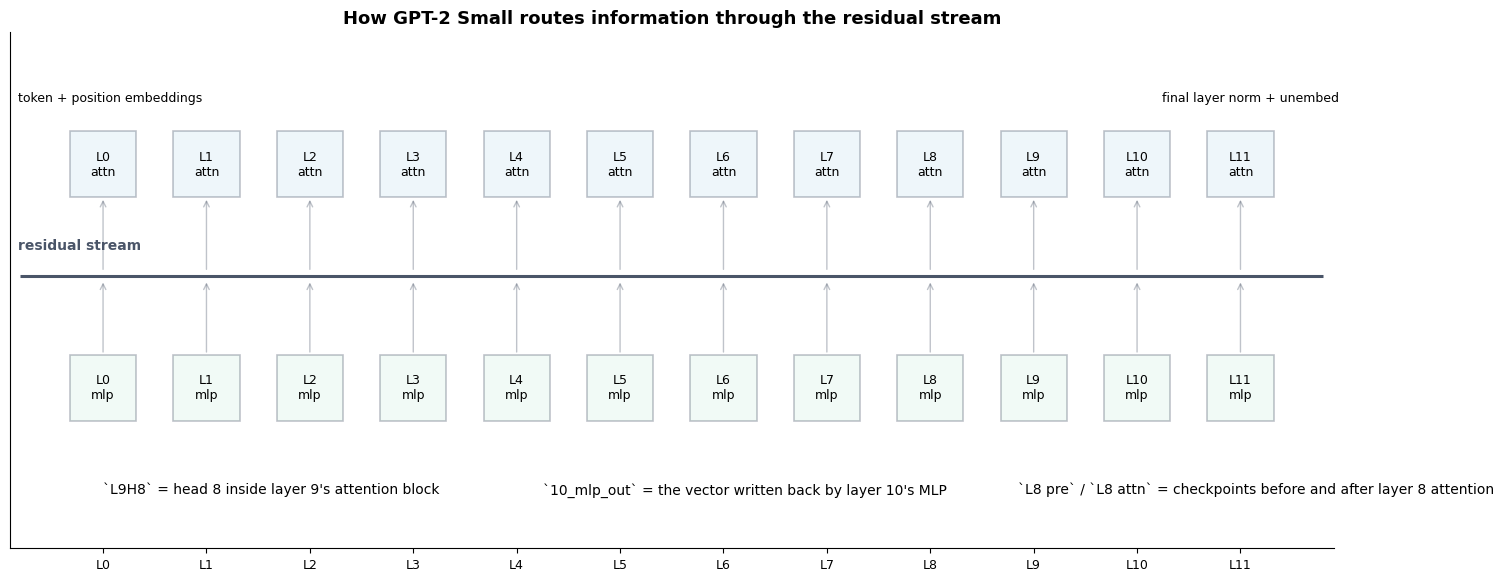

### Notation guide
These labels appear throughout the rest of the notebook. The plot above is the map that tells us where each one lives inside the computation.
- `L9H8`: Attention head 8 inside layer 9. The architecture map above shows it inside layer 9's attention block.
- `10_mlp_out`: The vector written back into the residual stream by layer 10's MLP.
- `L8 pre`: The residual stream just before layer 8 attention runs.
- `L8 attn`: The residual stream just after layer 8 attention writes back, but before the layer 8 MLP runs.
- `final post`: The final residual state after the last MLP write, just before the final layer norm and unembedding.

In [9]:
plot_model_architecture_overview(model)
plt.show()

display_field_guide(
    "Notation guide",
    {
        "L9H8": "Attention head 8 inside layer 9. The architecture map above shows it inside layer 9's attention block.",
        "10_mlp_out": "The vector written back into the residual stream by layer 10's MLP.",
        "L8 pre": "The residual stream just before layer 8 attention runs.",
        "L8 attn": "The residual stream just after layer 8 attention writes back, but before the layer 8 MLP runs.",
        "final post": "The final residual state after the last MLP write, just before the final layer norm and unembedding.",
    },
    intro="These labels appear throughout the rest of the notebook. The plot above is the map that tells us where each one lives inside the computation.",
)


In [10]:
with torch.no_grad():
    logits, cache = model.run_with_cache(tokens, remove_batch_dim=True)

final_logits = final_token_logits(logits).squeeze(0)
final_predictions_df = top_predictions_table(model, final_logits, k=TOP_K)
display(final_predictions_df)

display_field_guide(
    "How to read the next-token table",
    {
        "rank": "The token's position after sorting all vocabulary logits from highest to lowest.",
        "token": "The readable token string, with leading spaces shown as `[space]`.",
        "token_id": "The integer ID used internally by the tokenizer and model.",
        "probability": "The softmax probability at the final position after the full forward pass.",
    },
)

target_rank = get_token_rank(final_logits, target_token_id)
rival_rank = get_token_rank(final_logits, rival_token_id)
print(f"Final rank of {visible_token(TARGET_ANSWER)}: {target_rank}")
print(f"Final rank of {visible_token(RIVAL_ANSWER)}: {rival_rank}")


Final rank of [space]Berlin: 1
Final rank of [space]Paris: 14


,rank,token,token_id,probability
0,1,[space]Berlin,11307,0.3219
1,2,[space]Frankfurt,31970,0.1599
2,3,[space]Munich,22418,0.0857
3,4,[space]Dresden,46993,0.0749
4,5,[space]Hamburg,32526,0.0700
5,6,[space]Cologne,34923,0.0521
6,7,[space]Sch,3059,0.0103
7,8,[space]Vienna,23825,0.0093


### How to read the next-token table
- `rank`: The token's position after sorting all vocabulary logits from highest to lowest.
- `token`: The readable token string, with leading spaces shown as `[space]`.
- `token_id`: The integer ID used internally by the tokenizer and model.
- `probability`: The softmax probability at the final position after the full forward pass.

In [11]:
display_takeaways(
    title="Why start with the final prediction?",
    what="The model's next-token distribution after the full forward pass.",
    change=(f"For this prompt, {visible_token(TARGET_ANSWER)} finishes at rank {target_rank}, while {visible_token(RIVAL_ANSWER)} finishes at rank {rival_rank}."),
    why="Before we decompose anything, we want to verify that the model gives us a clean behavior worth explaining.",
    practice="This is the equivalent of validating the business outcome before spending time on root-cause analysis. If the top-line behavior is not real, the mechanistic story is not useful.",
)


### Why start with the final prediction?
- What we are looking at: The model's next-token distribution after the full forward pass.
- What changes here: For this prompt, [space]Berlin finishes at rank 1, while [space]Paris finishes at rank 14.
- Why it matters: Before we decompose anything, we want to verify that the model gives us a clean behavior worth explaining.
- Why this matters in practice: This is the equivalent of validating the business outcome before spending time on root-cause analysis. If the top-line behavior is not real, the mechanistic story is not useful.

## 2. Does the answer appear all at once?

We start with the simplest possible test. If the answer only snaps into place at the very end, the later causal sections should probably focus on the final blocks. If it emerges gradually, we should expect a distributed story where different checkpoints reshape the candidate set over time.


In [12]:
accum_resid, checkpoint_labels = cache.accumulated_resid(
    layer=-1,
    incl_mid=True,
    return_labels=True,
)

resid_last_pos = accum_resid[:, -1, :]
resid_normed = model.ln_final(accum_resid)
checkpoint_logits = model.unembed(resid_normed)
checkpoint_logits_last_pos = checkpoint_logits[:, -1, :]

checkpoint_df = build_checkpoint_dataframe(
    model=model,
    checkpoint_labels=checkpoint_labels,
    checkpoint_logits_last_pos=checkpoint_logits_last_pos,
    resid_last_pos=resid_last_pos,
    target_token=target_token_id,
    rival_token=rival_token_id,
)

candidate_token_ids = choose_candidate_token_ids(
    checkpoint_logits_last_pos,
    target_token=target_token_id,
    rival_token=rival_token_id,
    max_tokens=7,
)
candidate_labels, candidate_matrix = build_candidate_matrix(
    model,
    checkpoint_logits_last_pos,
    candidate_token_ids,
)

display(Markdown("### Checkpoint-by-checkpoint trace"))
display(checkpoint_df)

display_field_guide(
    "How to read the checkpoint table",
    {
        "checkpoint_idx": "The order of this checkpoint in the forward pass.",
        "label": "TransformerLens' raw checkpoint name such as `8_mid`.",
        "label_short": "A more readable label such as `L8 attn`.",
        "layer": "Which transformer block this checkpoint belongs to.",
        "phase": "Whether the checkpoint is before attention, after attention, or after the MLP.",
        "target_token / rival_token": "The two tokens whose competition we track throughout the notebook.",
        "target_prob / rival_prob": "The softmax probability of each token if we stopped the run at that checkpoint.",
        "logit_diff": "Target logit minus rival logit. Positive means the answer is winning even if both probabilities are still small.",
        "target_rank / rival_rank": "The rank of each token among the full vocabulary at that checkpoint.",
        "top_prediction": "The token currently in first place at that checkpoint.",
        "residual_norm": "The L2 size of the residual state at that checkpoint.",
    },
    intro="This table is the backbone of the notebook. Each row is one stop along the forward pass, always measured at the final position where the next token will be predicted.",
)


### Checkpoint-by-checkpoint trace

,checkpoint_idx,label,label_short,layer,phase,target_token,rival_token,target_prob,rival_prob,logit_diff,target_rank,rival_rank,top_prediction,residual_norm
0,0,0_pre,L0 pre,0.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,0.1762,26717,27603,[space]destro,4.6034
1,1,0_mid,L0 attn,0.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,0.0471,15575,15850,[space]very,28.3381
2,2,1_pre,L1 pre,1.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,1.4875,7778,15549,[space]not,54.5633
3,3,1_mid,L1 attn,1.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.1030,4211,12001,[space]now,53.9710
4,4,2_pre,L2 pre,2.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.2996,4972,14682,[space]now,55.9073
5,5,2_mid,L2 attn,2.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.3997,3072,10534,[space]now,58.3127
6,6,3_pre,L3 pre,3.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.5244,4114,13902,[space]now,57.6643
7,7,3_mid,L3 attn,3.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,3.2047,2341,11641,[space]also,59.6797
8,8,4_pre,L4 pre,4.0000,pre-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.2691,3076,9244,[space]also,60.4477
9,9,4_mid,L4 attn,4.0000,post-attn,[space]Berlin,[space]Paris,0.0000,0.0000,2.1128,1400,4400,[space]also,63.3420


### How to read the checkpoint table
This table is the backbone of the notebook. Each row is one stop along the forward pass, always measured at the final position where the next token will be predicted.
- `checkpoint_idx`: The order of this checkpoint in the forward pass.
- `label`: TransformerLens' raw checkpoint name such as `8_mid`.
- `label_short`: A more readable label such as `L8 attn`.
- `layer`: Which transformer block this checkpoint belongs to.
- `phase`: Whether the checkpoint is before attention, after attention, or after the MLP.
- `target_token / rival_token`: The two tokens whose competition we track throughout the notebook.
- `target_prob / rival_prob`: The softmax probability of each token if we stopped the run at that checkpoint.
- `logit_diff`: Target logit minus rival logit. Positive means the answer is winning even if both probabilities are still small.
- `target_rank / rival_rank`: The rank of each token among the full vocabulary at that checkpoint.
- `top_prediction`: The token currently in first place at that checkpoint.
- `residual_norm`: The L2 size of the residual state at that checkpoint.

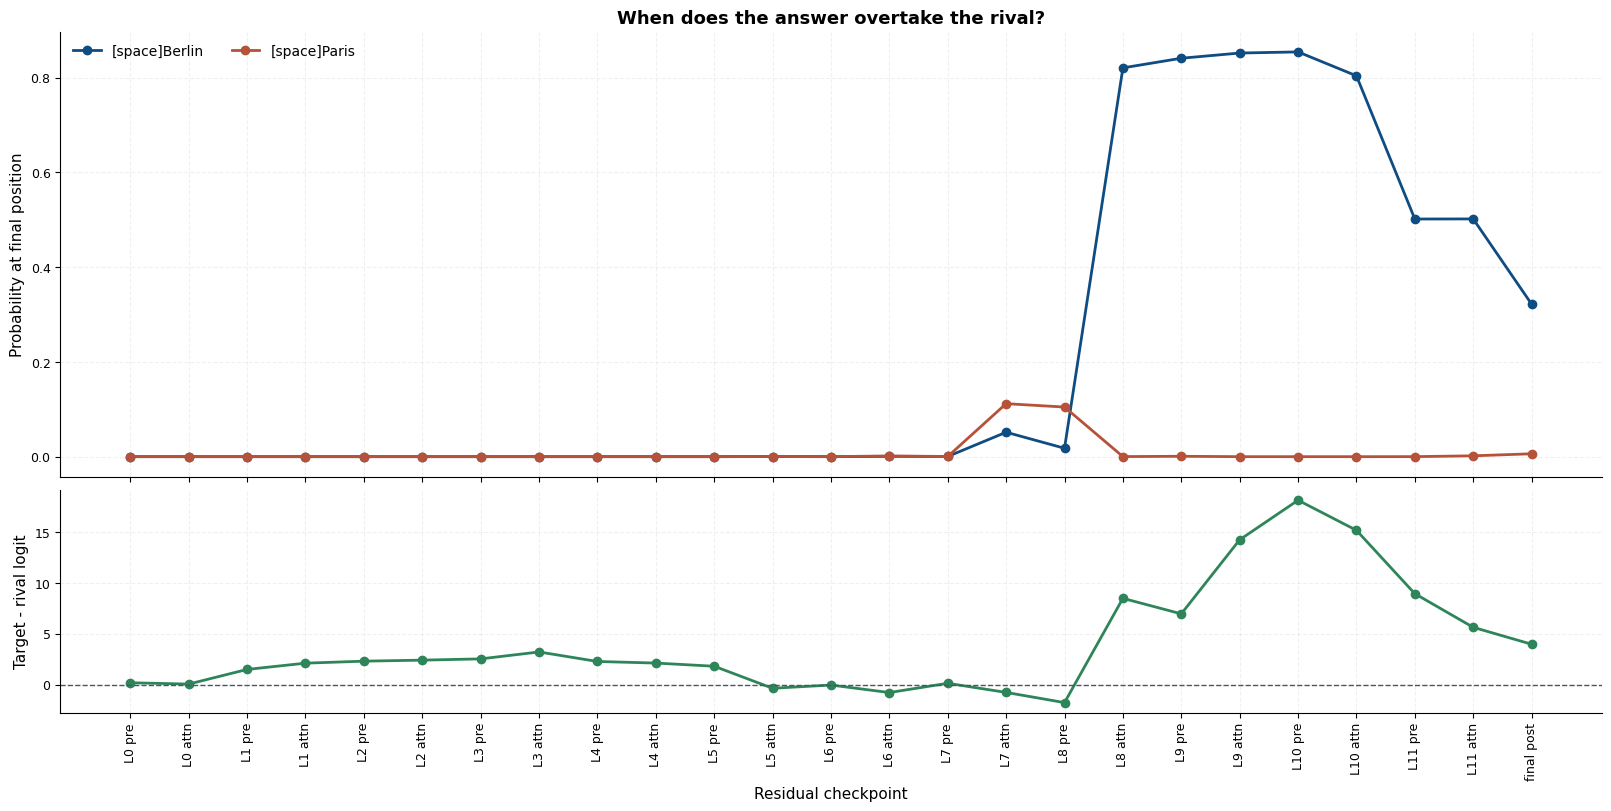

In [13]:
plot_emergence_overview(checkpoint_df)
plt.show()


In [14]:
target_beats_rival = checkpoint_df.loc[checkpoint_df["logit_diff"] > 0, "label_short"]
target_reaches_top10 = checkpoint_df.loc[checkpoint_df["target_rank"] <= 10, "label_short"]
target_reaches_top = checkpoint_df.loc[checkpoint_df["target_rank"] == 1, "label_short"]
first_target_beats_rival = target_beats_rival.iloc[0] if not target_beats_rival.empty else "never"
first_target_top10 = target_reaches_top10.iloc[0] if not target_reaches_top10.empty else "never"
first_target_top = target_reaches_top.iloc[0] if not target_reaches_top.empty else "never"
opening_top = checkpoint_df.iloc[0]["top_prediction"]

display_takeaways(
    title="Reading the emergence plot",
    what="The target probability, rival probability, and target-minus-rival logit gap at each residual checkpoint.",
    change=(f"The checkpoint sequence opens with {opening_top} as the top candidate, {visible_token(TARGET_ANSWER)} first edges above {visible_token(RIVAL_ANSWER)} at {first_target_beats_rival}, enters the top 10 at {first_target_top10}, and first becomes rank 1 at {first_target_top}."),
    why="This shows that the answer is assembled over time rather than appearing in one last-step jump. Early positive logit margin over the rival does not mean the answer is already strong overall; it only means ` Berlin` is slightly ahead of ` Paris` inside a still very weak part of the distribution.",
    practice="When a model starts behaving differently after a release, this kind of timeline helps a delivery team narrow the search to a specific stage of the forward pass instead of relying on a vague before-versus-after comparison.",
)


### Reading the emergence plot
- What we are looking at: The target probability, rival probability, and target-minus-rival logit gap at each residual checkpoint.
- What changes here: The checkpoint sequence opens with [space]destro as the top candidate, [space]Berlin first edges above [space]Paris at L0 pre, enters the top 10 at L7 attn, and first becomes rank 1 at L8 attn.
- Why it matters: This shows that the answer is assembled over time rather than appearing in one last-step jump. Early positive logit margin over the rival does not mean the answer is already strong overall; it only means ` Berlin` is slightly ahead of ` Paris` inside a still very weak part of the distribution.
- Why this matters in practice: When a model starts behaving differently after a release, this kind of timeline helps a delivery team narrow the search to a specific stage of the forward pass instead of relying on a vague before-versus-after comparison.

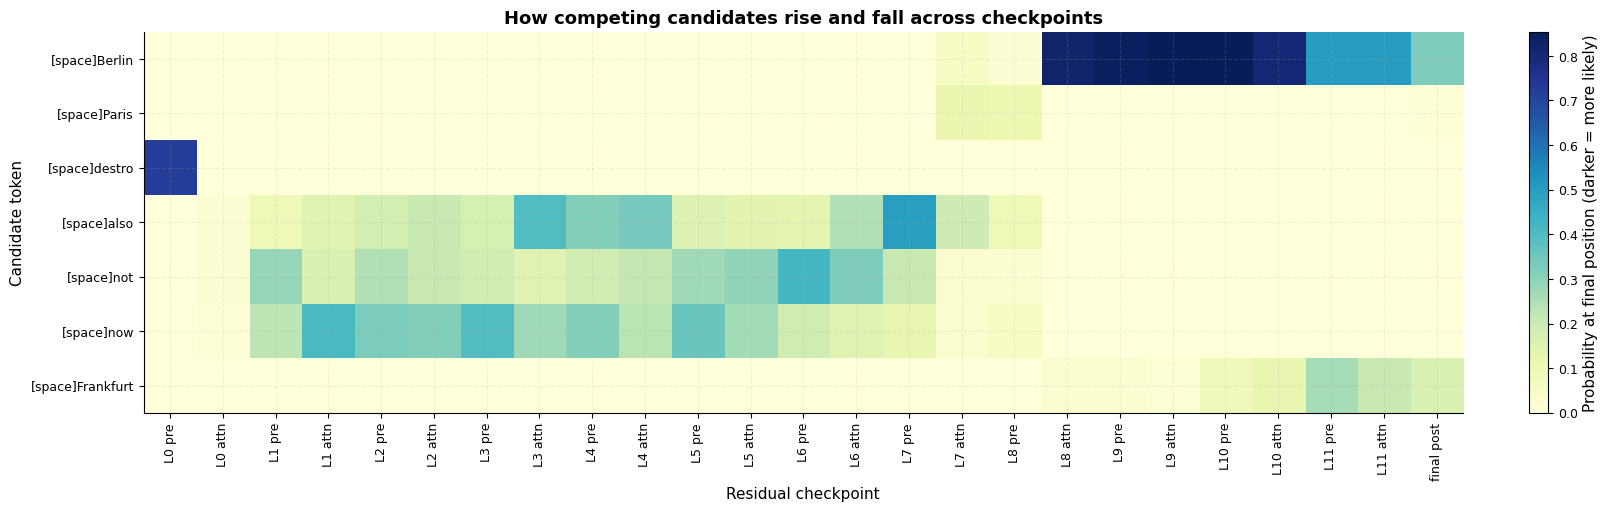

In [15]:
plot_candidate_heatmap(candidate_labels, candidate_matrix, checkpoint_df["label_short"].tolist())
plt.show()


In [16]:
opening_top_token_id = int(F.softmax(checkpoint_logits_last_pos[0], dim=-1).argmax().item())
opening_top_raw = token_id_to_str(model, opening_top_token_id)

peak_target_idx = int(checkpoint_df["target_prob"].idxmax())
peak_target_label = checkpoint_df.loc[peak_target_idx, "label_short"]
peak_target_prob = checkpoint_df.loc[peak_target_idx, "target_prob"]
final_target_prob = checkpoint_df.iloc[-1]["target_prob"]
post_peak_drop = peak_target_prob - final_target_prob

display_takeaways(
    title="Reading the competition heatmap",
    what="A small set of candidate tokens tracked across the same checkpoints, with darker colors meaning higher probability.",
    change=(f"{visible_token(TARGET_ANSWER)} peaks at {peak_target_label} with probability {peak_target_prob:0.3f}, then falls by {post_peak_drop:0.3f} by the final checkpoint while still staying in first place."),
    why="Peak confidence and final confidence are not the same thing. Once the model has effectively chosen ` Berlin`, later blocks can still rebalance probability mass without changing the winner.",
    practice="For debugging, this warns us not to confuse a late drop in confidence with a total failure. A workflow can keep the same top answer while still changing how fragile that answer is.",
    caveat="This is an interpretation of one run, not a universal rule about all prompts or all models.",
)

display(Markdown(
    f"Tokenizer note: the early candidate {visible_token(opening_top_raw)} is a GPT-2 token fragment (`{opening_top_raw}`). Early checkpoints can surface odd fragments because the model has not yet assembled enough task-specific evidence for the country-capital pattern to dominate the distribution."
))


### Reading the competition heatmap
- What we are looking at: A small set of candidate tokens tracked across the same checkpoints, with darker colors meaning higher probability.
- What changes here: [space]Berlin peaks at L10 pre with probability 0.854, then falls by 0.532 by the final checkpoint while still staying in first place.
- Why it matters: Peak confidence and final confidence are not the same thing. Once the model has effectively chosen ` Berlin`, later blocks can still rebalance probability mass without changing the winner.
- Why this matters in practice: For debugging, this warns us not to confuse a late drop in confidence with a total failure. A workflow can keep the same top answer while still changing how fragile that answer is.
- Caveat: This is an interpretation of one run, not a universal rule about all prompts or all models.

Tokenizer note: the early candidate [space]destro is a GPT-2 token fragment (` destro`). Early checkpoints can surface odd fragments because the model has not yet assembled enough task-specific evidence for the country-capital pattern to dominate the distribution.

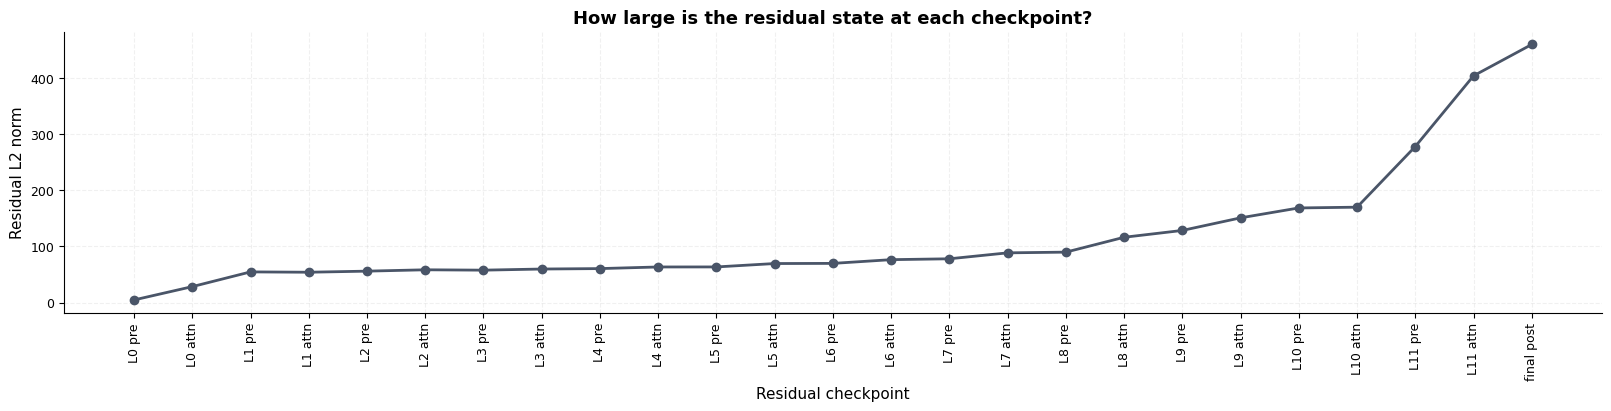

In [17]:
plot_residual_norm(checkpoint_df)
plt.show()


In [18]:
biggest_norm_jump = checkpoint_df["residual_norm"].diff().abs().fillna(0).idxmax()
biggest_norm_label = checkpoint_df.loc[biggest_norm_jump, "label_short"]
biggest_norm_delta = checkpoint_df["residual_norm"].diff().abs().fillna(0).max()

display_takeaways(
    title="Reading the residual norm plot",
    what="The L2 norm of the accumulated residual stream at the final position across checkpoints.",
    change=(f"The largest checkpoint-to-checkpoint norm change lands at {biggest_norm_label}, with an absolute jump of {biggest_norm_delta:0.3f}."),
    why="This plot is about state size, not correctness. A larger residual vector means the model is carrying more total signal, but not all signal points toward ` Berlin`. That is why the norm can keep growing even when answer confidence softens a little later on.",
    practice="In a release triage setting, a large norm jump can be a useful clue about where the network is rewriting the state most aggressively, even before we know whether the rewrite is beneficial.",
)


### Reading the residual norm plot
- What we are looking at: The L2 norm of the accumulated residual stream at the final position across checkpoints.
- What changes here: The largest checkpoint-to-checkpoint norm change lands at L11 attn, with an absolute jump of 125.911.
- Why it matters: This plot is about state size, not correctness. A larger residual vector means the model is carrying more total signal, but not all signal points toward ` Berlin`. That is why the norm can keep growing even when answer confidence softens a little later on.
- Why this matters in practice: In a release triage setting, a large norm jump can be a useful clue about where the network is rewriting the state most aggressively, even before we know whether the rewrite is beneficial.

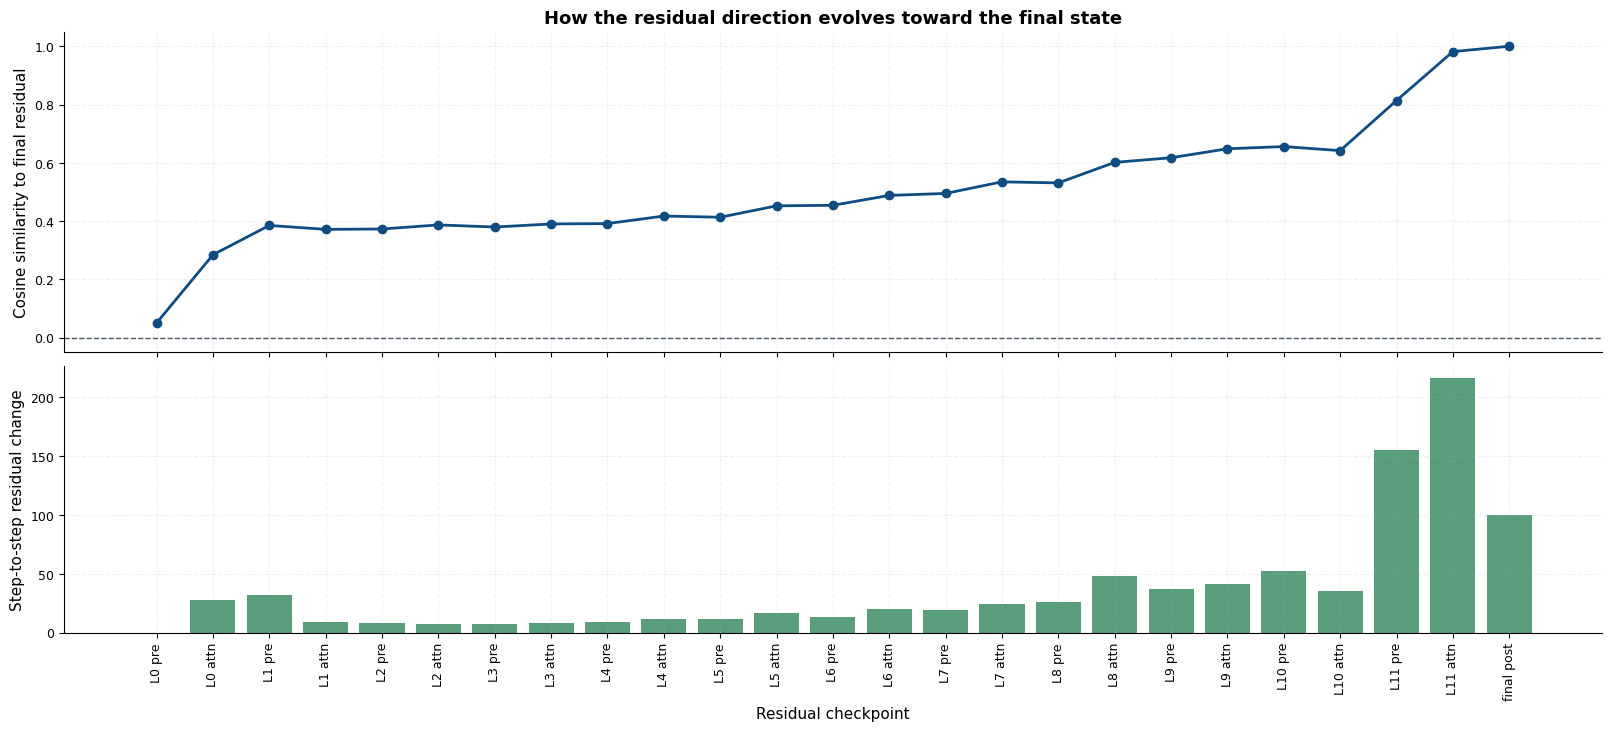

In [19]:
cosine_to_final, step_delta_norm = compute_residual_trajectory_metrics(resid_last_pos)
plot_residual_trajectory(checkpoint_df, cosine_to_final, step_delta_norm)
plt.show()


In [20]:
best_alignment_idx = int(np.argmax(cosine_to_final))
best_alignment_label = checkpoint_df.loc[best_alignment_idx, "label_short"]
biggest_move_idx = int(np.argmax(step_delta_norm))
biggest_move_label = checkpoint_df.loc[biggest_move_idx, "label_short"]

display_takeaways(
    title="Reading the residual trajectory view",
    what="Cosine similarity to the final residual state and the size of each checkpoint-to-checkpoint move.",
    change=(f"The residual direction is most aligned with the final state at {best_alignment_label}, while the single biggest move lands at {biggest_move_label}."),
    why="This gives us a more direct picture of how the model's internal state evolves, not just how large it becomes.",
    practice="When a model keeps the same top answer but feels less stable after an update, direction and step-size views can reveal whether the internal route changed even if the final output did not.",
)


### Reading the residual trajectory view
- What we are looking at: Cosine similarity to the final residual state and the size of each checkpoint-to-checkpoint move.
- What changes here: The residual direction is most aligned with the final state at final post, while the single biggest move lands at L11 attn.
- Why it matters: This gives us a more direct picture of how the model's internal state evolves, not just how large it becomes.
- Why this matters in practice: When a model keeps the same top answer but feels less stable after an update, direction and step-size views can reveal whether the internal route changed even if the final output did not.

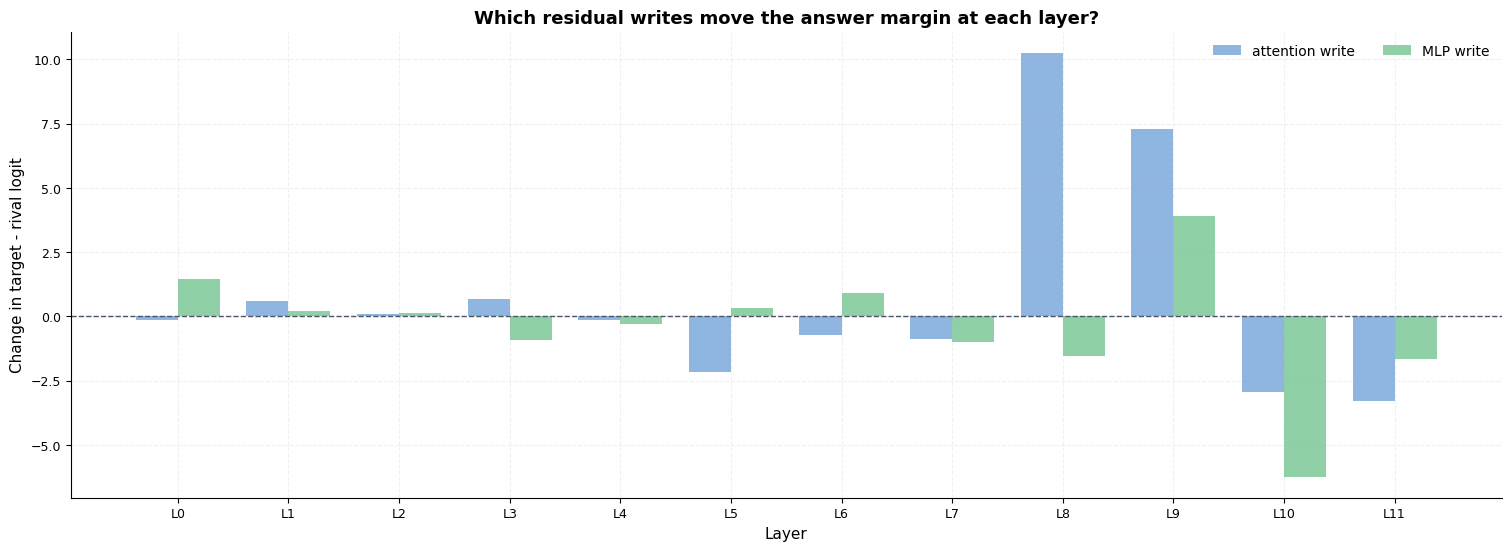

In [21]:
layer_delta_df = build_layer_delta_dataframe(checkpoint_df, model.cfg.n_layers)
plot_layer_delta_story(layer_delta_df)
plt.show()


In [22]:
strongest_attn_row = layer_delta_df.loc[layer_delta_df["attn_delta"].idxmax()]
strongest_mlp_row = layer_delta_df.loc[layer_delta_df["mlp_delta"].idxmax()]

first_top10_idx = int(checkpoint_df.index[checkpoint_df["target_rank"] <= 10][0])
first_top_idx = int(checkpoint_df.index[checkpoint_df["target_rank"] == 1][0])
early_end_label = checkpoint_df.loc[max(first_top10_idx - 1, 0), "label_short"]
stage_two_end_label = checkpoint_df.loc[max(first_top_idx - 1, first_top10_idx), "label_short"]

display_takeaways(
    title="Reading the residual-write view",
    what="Per-layer changes in the target-minus-rival margin, split into attention writes and MLP writes.",
    change=(
        f"The strongest attention jump appears in layer {int(strongest_attn_row['layer'])} "
        f"({strongest_attn_row['attn_delta']:0.3f}), while the strongest MLP jump appears in layer "
        f"{int(strongest_mlp_row['layer'])} ({strongest_mlp_row['mlp_delta']:0.3f})."
    ),
    why="This separates two different jobs in the residual stream: routing context with attention versus refining the representation with the MLP write.",
    practice="When a model behavior regresses, this split helps distinguish whether the failure came from reading the wrong context or from rewriting the right context badly.",
)

display(
    Markdown(
        "\n".join(
            [
                "### A staged reading of the residual stream",
                f"1. **Stage 1 - weak lexical priors ({checkpoint_df.iloc[0]['label_short']} to {early_end_label})**: the model is still dominated by generic continuations and odd tokenizer fragments, so ` Berlin` is present but nowhere near the top.",
                f"2. **Stage 2 - the answer becomes a serious candidate ({first_target_top10} to {stage_two_end_label})**: ` Berlin` enters the shortlist of realistic next tokens, but the model is still juggling alternatives and has not committed to the answer yet.",
                f"3. **Stage 3 - decisive late routing ({first_target_top} to {peak_target_label})**: late attention-centered writes create the sharpest jump in the answer margin and push ` Berlin` into first place.",
                f"4. **Stage 4 - confidence rebalancing ({peak_target_label} to final post)**: later writes redistribute some probability mass after the peak, but the winner stays fixed and the residual direction remains close to the finished answer state.",
            ]
        )
    )
)


### Reading the residual-write view
- What we are looking at: Per-layer changes in the target-minus-rival margin, split into attention writes and MLP writes.
- What changes here: The strongest attention jump appears in layer 8 (10.252), while the strongest MLP jump appears in layer 9 (3.889).
- Why it matters: This separates two different jobs in the residual stream: routing context with attention versus refining the representation with the MLP write.
- Why this matters in practice: When a model behavior regresses, this split helps distinguish whether the failure came from reading the wrong context or from rewriting the right context badly.

### A staged reading of the residual stream
1. **Stage 1 - weak lexical priors (L0 pre to L7 pre)**: the model is still dominated by generic continuations and odd tokenizer fragments, so ` Berlin` is present but nowhere near the top.
2. **Stage 2 - the answer becomes a serious candidate (L7 attn to L8 pre)**: ` Berlin` enters the shortlist of realistic next tokens, but the model is still juggling alternatives and has not committed to the answer yet.
3. **Stage 3 - decisive late routing (L8 attn to L10 pre)**: late attention-centered writes create the sharpest jump in the answer margin and push ` Berlin` into first place.
4. **Stage 4 - confidence rebalancing (L10 pre to final post)**: later writes redistribute some probability mass after the peak, but the winner stays fixed and the residual direction remains close to the finished answer state.

## 3. Which components start pushing ` Berlin` upward?

The timeline above tells us **when** the answer becomes visible. Now we need a shortlist of suspects. Direct logit attribution asks a very local question: if we look at one residual contributor at the final position, does it push the logit of ` Berlin` up or down?

### What direct logit attribution means in plain English

At the final position, every attention block and every MLP writes a vector into the residual stream. Direct logit attribution projects one of those vectors through the final unembedding and asks how much it helps or hurts the target token.

- Positive attribution means the component pushes ` Berlin` upward.
- Negative attribution means the component pushes ` Berlin` downward.
- Large positive values do **not** prove necessity on their own. They tell us which components deserve causal follow-up.


In [23]:
resid_all, labels_all = cache.decompose_resid(layer=model.cfg.n_layers, mode="all", return_labels=True)
resid_attn, labels_attn = cache.decompose_resid(layer=model.cfg.n_layers, mode="attn", return_labels=True)
resid_mlp, labels_mlp = cache.decompose_resid(layer=model.cfg.n_layers, mode="mlp", return_labels=True)
head_results = cache.stack_head_results(layer=model.cfg.n_layers, return_labels=False)

dla_all_df = attrs_to_df(labels_all, cache.logit_attrs(resid_all, TARGET_ANSWER))
dla_attn_df = attrs_to_df(labels_attn, cache.logit_attrs(resid_attn, TARGET_ANSWER))
dla_mlp_df = attrs_to_df(labels_mlp, cache.logit_attrs(resid_mlp, TARGET_ANSWER))
head_attr_df = head_attrs_to_df(model, cache.logit_attrs(head_results, TARGET_ANSWER))

display(Markdown("### First suspect list"))
display(Markdown("These rankings turn the full model into a short list of residual contributors and heads worth inspecting more closely."))

display(Markdown("### Top residual contributors"))
display(dla_all_df.head(10))
display_field_guide(
    "How to read the residual-contributor table",
    {
        "component": "The named residual contributor, such as an attention output or MLP output.",
        "logit_attr": "How much that component pushes the logit of the answer token at the final position.",
    },
)

display(Markdown("### Top attention heads by direct logit attribution"))
display(head_attr_df.head(10))
display_field_guide(
    "How to read the attention-head table",
    {
        "layer": "Which transformer block the head belongs to.",
        "head": "Which head inside that layer we are looking at.",
        "label": "A readable shorthand such as `L9H8`.",
        "logit_attr": "How much that head's output pushes the answer token upward at the final position.",
    },
)


### First suspect list

These rankings turn the full model into a short list of residual contributors and heads worth inspecting more closely.

### Top residual contributors

,component,logit_attr
0,9_mlp_out,4.1132
1,9_attn_out,4.1024
2,8_attn_out,3.6786
3,10_attn_out,1.3749
4,7_attn_out,1.2171
5,8_mlp_out,1.0243
6,10_mlp_out,0.7278
7,6_attn_out,0.6837
8,5_attn_out,0.6444
9,11_attn_out,0.3972


### How to read the residual-contributor table
- `component`: The named residual contributor, such as an attention output or MLP output.
- `logit_attr`: How much that component pushes the logit of the answer token at the final position.

### Top attention heads by direct logit attribution

,layer,head,label,logit_attr
0,9,8,L9H8,3.5336
1,8,11,L8H11,2.7069
2,10,0,L10H0,1.2767
3,8,6,L8H6,0.8963
4,10,3,L10H3,0.8028
5,11,3,L11H3,0.6526
6,8,8,L8H8,0.6497
7,7,7,L7H7,0.5959
8,5,0,L5H0,0.3137
9,0,8,L0H8,0.3038


### How to read the attention-head table
- `layer`: Which transformer block the head belongs to.
- `head`: Which head inside that layer we are looking at.
- `label`: A readable shorthand such as `L9H8`.
- `logit_attr`: How much that head's output pushes the answer token upward at the final position.

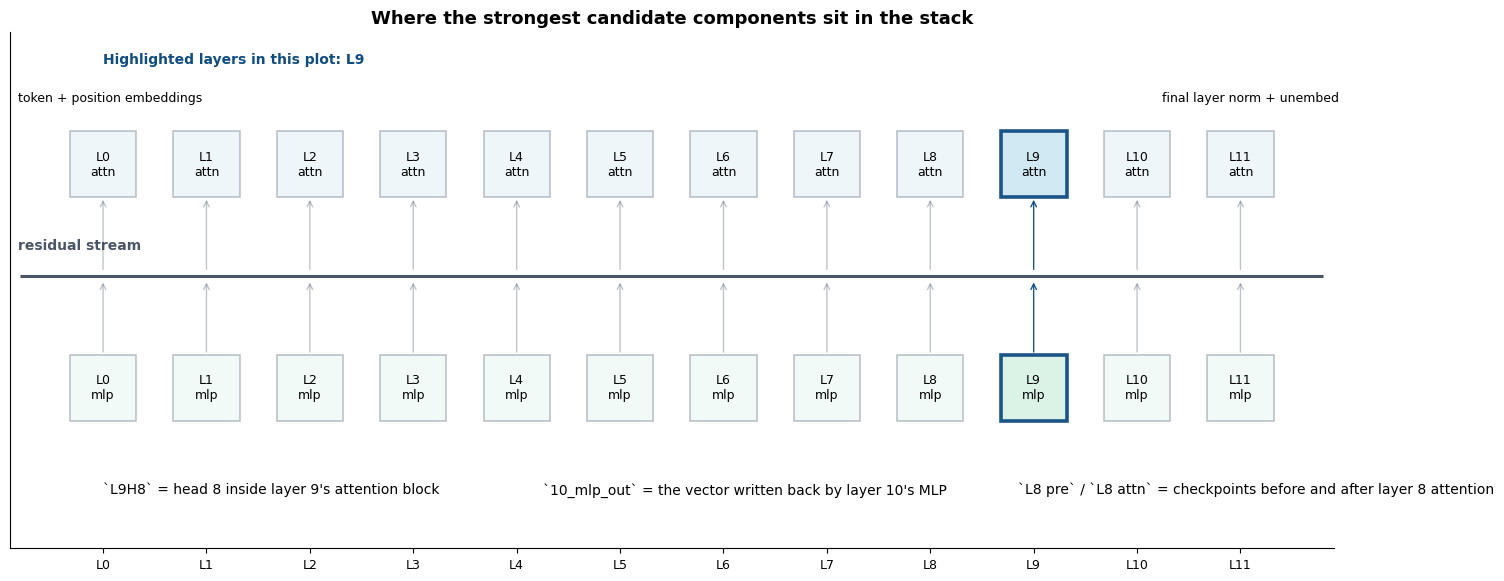

In [24]:
top_component = dla_all_df.iloc[0]
top_attention_head = head_attr_df.iloc[0]
highlighted_layers = sorted(
    {
        layer
        for layer in [
            component_to_layer(top_component["component"]),
            int(top_attention_head["layer"]),
        ]
        if layer is not None
    }
)

plot_model_architecture_overview(
    model,
    highlight_layers=highlighted_layers,
    title="Where the strongest candidate components sit in the stack",
)
plt.show()


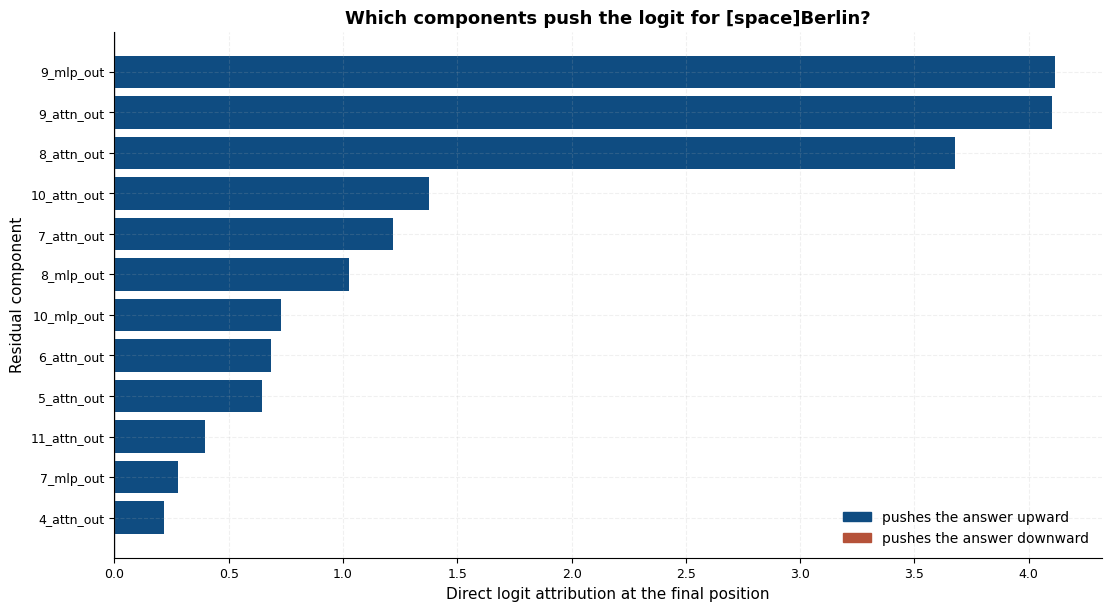

In [25]:
plot_component_attribution(dla_all_df, TARGET_ANSWER, top_n=TOP_COMPONENTS)
plt.show()


In [26]:
display_takeaways(
    title="Reading the attribution view",
    what="Direct logit attribution scores for residual components and individual attention heads at the final position.",
    change=(f"The strongest overall component is {top_component['component']} with attribution {top_component['logit_attr']:0.3f}, and the strongest attention head is {top_attention_head['label']} with attribution {top_attention_head['logit_attr']:0.3f}."),
    why="This is our first concrete hypothesis about where the answer is being pushed upward inside the network.",
    practice="Attribution turns a large model into a short audit list, which is far more practical when teams need to explain or validate a behavior under delivery timelines.",
    caveat="Attribution is still descriptive. A component can score highly because it writes useful evidence, because it cleans up earlier evidence, or because it correlates with another component that matters more.",
)


### Reading the attribution view
- What we are looking at: Direct logit attribution scores for residual components and individual attention heads at the final position.
- What changes here: The strongest overall component is 9_mlp_out with attribution 4.113, and the strongest attention head is L9H8 with attribution 3.534.
- Why it matters: This is our first concrete hypothesis about where the answer is being pushed upward inside the network.
- Why this matters in practice: Attribution turns a large model into a short audit list, which is far more practical when teams need to explain or validate a behavior under delivery timelines.
- Caveat: Attribution is still descriptive. A component can score highly because it writes useful evidence, because it cleans up earlier evidence, or because it correlates with another component that matters more.

## 4. Do those heads read from the right places?

Attribution gives us a shortlist, but it does not tell us whether those heads are reading anything plausible. Attention patterns are still descriptive, not causal, yet they let us sanity-check whether the candidate heads look like they are routing from tokens that could actually support the answer.

### How to read the attention maps

- Rows are destination positions: which token is doing the reading.
- Columns are source positions: which token is being read from.
- Darker cells mean more attention weight from the row token to the column token.
- We care most about the **last row**, because that is the position making the next-token prediction.


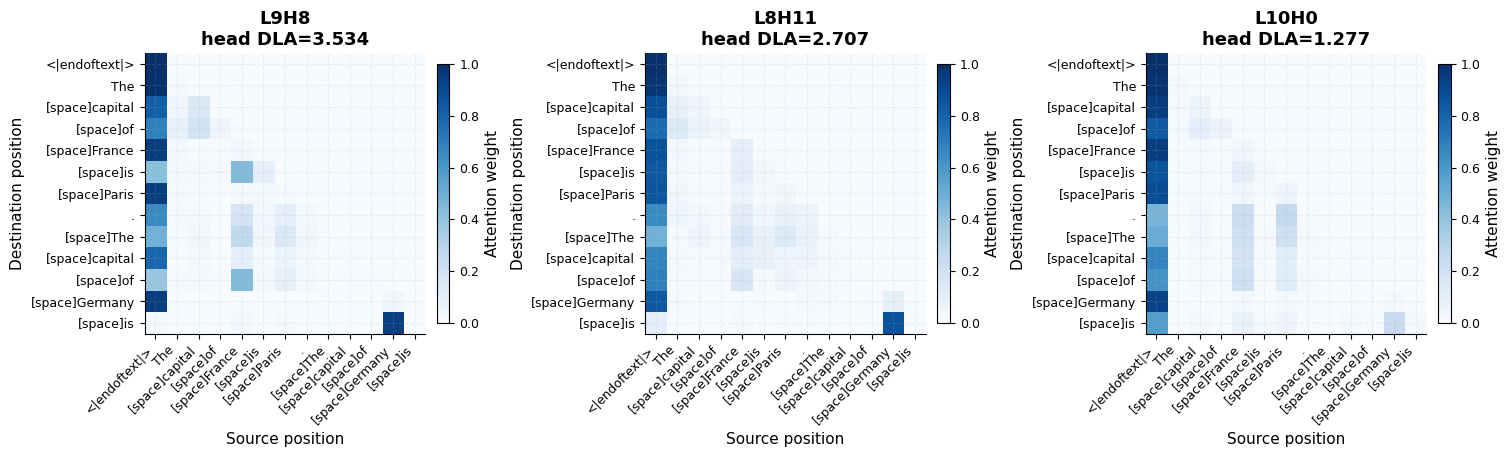

In [27]:
attention_heads_df = head_attr_df.head(HEADS_TO_VISUALIZE).copy()
plot_attention_heads(cache, attention_heads_df, str_tokens)
plt.show()


In [28]:
head_summaries = []
for row in attention_heads_df.itertuples(index=False):
    pattern = cache["pattern", int(row.layer)][int(row.head)].detach().cpu().numpy()
    last_query = pattern[-1]
    source_idx = int(last_query.argmax())
    source_token = visible_token(str_tokens[source_idx])
    source_weight = float(last_query[source_idx])
    head_summaries.append(
        f"- `{row.label}`: the final query position reads most strongly from `{source_token}` with attention weight {source_weight:0.3f}."
    )

top_head_row = attention_heads_df.iloc[0]
top_pattern = cache["pattern", int(top_head_row["layer"])][int(top_head_row["head"])].detach().cpu().numpy()
top_last_query = top_pattern[-1]
top_source_idx = int(top_last_query.argmax())
top_source_token = visible_token(str_tokens[top_source_idx])
top_source_weight = float(top_last_query[top_source_idx])

display_takeaways(
    title="Reading the attention patterns",
    what="Static attention maps for the most attribution-heavy heads.",
    change=(f"For the top head {top_head_row['label']}, the final query position pays its largest attention weight to {top_source_token} with weight {top_source_weight:0.3f}."),
    why="When a candidate head attends to a token that plausibly supports the answer, the mechanistic story becomes more coherent before we even intervene causally.",
    practice="This kind of routing check is useful when someone asks whether a model behavior looks interpretable enough to trust, escalate, or investigate further.",
    caveat="Attention patterns are not causal proof. A head can look intuitive in the plot and still be non-essential once we intervene on the computation.",
)

display(Markdown("### What each plotted head seems to read\n" + "\n".join(head_summaries)))


### Reading the attention patterns
- What we are looking at: Static attention maps for the most attribution-heavy heads.
- What changes here: For the top head L9H8, the final query position pays its largest attention weight to [space]Germany with weight 0.939.
- Why it matters: When a candidate head attends to a token that plausibly supports the answer, the mechanistic story becomes more coherent before we even intervene causally.
- Why this matters in practice: This kind of routing check is useful when someone asks whether a model behavior looks interpretable enough to trust, escalate, or investigate further.
- Caveat: Attention patterns are not causal proof. A head can look intuitive in the plot and still be non-essential once we intervene on the computation.

### What each plotted head seems to read
- `L9H8`: the final query position reads most strongly from `[space]Germany` with attention weight 0.939.
- `L8H11`: the final query position reads most strongly from `[space]Germany` with attention weight 0.864.
- `L10H0`: the final query position reads most strongly from `<|endoftext|>` with attention weight 0.569.

## 5. Can the hypothesis survive a causal test?

Up to this point, we have a descriptive story: when the answer appears, which components score highly, and where the strongest heads are looking. Patching is where that story has to earn its keep. If the attribution story is meaningful, restoring activations in the same neighborhood should recover the clean behavior.

### Clean vs. corrupted prompts

The causal test compares two prompts with the same token length:

- the **clean** prompt, where the model should answer with ` Berlin`
- the **corrupted** prompt, where the second sentence points back to France and makes ` Paris` much more plausible

Activation patching copies one activation from the clean run into the corrupted run and asks how much of the clean behavior comes back.


In [29]:
clean_tokens = model.to_tokens(CLEAN_PROMPT)
corrupted_tokens = model.to_tokens(CORRUPTED_PROMPT)
assert clean_tokens.shape == corrupted_tokens.shape, "Clean and corrupted prompts must have the same token length."

with torch.inference_mode():
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

metric = make_metric_for_answer(target_token_id, rival_token_id)
clean_score = metric(clean_logits).item()
corrupted_score = metric(corrupted_logits).item()

display_story_card(
    "Patch setup",
    {
        "Clean prompt": f"`{CLEAN_PROMPT}`",
        "Clean metric": f"{clean_score:0.3f}",
        "Corrupted prompt": f"`{CORRUPTED_PROMPT}`",
        "Corrupted metric": f"{corrupted_score:0.3f}",
    },
)

display_field_guide(
    "How to read the patch setup",
    {
        "Clean prompt": "The version of the prompt where the model should prefer ` Berlin`.",
        "Corrupted prompt": "The matched-length prompt that nudges the model toward ` Paris` instead.",
        "Metric": "Target logit minus rival logit at the final position. Higher means the model is preferring ` Berlin` more strongly than ` Paris`.",
    },
)


### Patch setup
- **Clean prompt:** `The capital of France is Paris. The capital of Germany is`
- **Clean metric:** 3.964
- **Corrupted prompt:** `The capital of France is Paris. The capital of France is`
- **Corrupted metric:** -8.043

### How to read the patch setup
- `Clean prompt`: The version of the prompt where the model should prefer ` Berlin`.
- `Corrupted prompt`: The matched-length prompt that nudges the model toward ` Paris` instead.
- `Metric`: Target logit minus rival logit at the final position. Higher means the model is preferring ` Berlin` more strongly than ` Paris`.

In [30]:
display_takeaways(
    title="Why define a clean-versus-corrupted pair?",
    what="A before-and-after setup for the same prompt shape, measured with a target-minus-rival metric.",
    change=(f"The clean run scores {clean_score:0.3f}, while the corrupted run falls to {corrupted_score:0.3f}."),
    why="Patching only makes sense if the clean and corrupted runs separate the behavior we care about. That separation gives us room to ask which copied activations restore the answer.",
    practice="This is the mechanistic equivalent of controlled A/B diagnosis: hold the prompt shape fixed, change the cue, and see which internal states recover the desired behavior.",
)


### Why define a clean-versus-corrupted pair?
- What we are looking at: A before-and-after setup for the same prompt shape, measured with a target-minus-rival metric.
- What changes here: The clean run scores 3.964, while the corrupted run falls to -8.043.
- Why it matters: Patching only makes sense if the clean and corrupted runs separate the behavior we care about. That separation gives us room to ask which copied activations restore the answer.
- Why this matters in practice: This is the mechanistic equivalent of controlled A/B diagnosis: hold the prompt shape fixed, change the cue, and see which internal states recover the desired behavior.

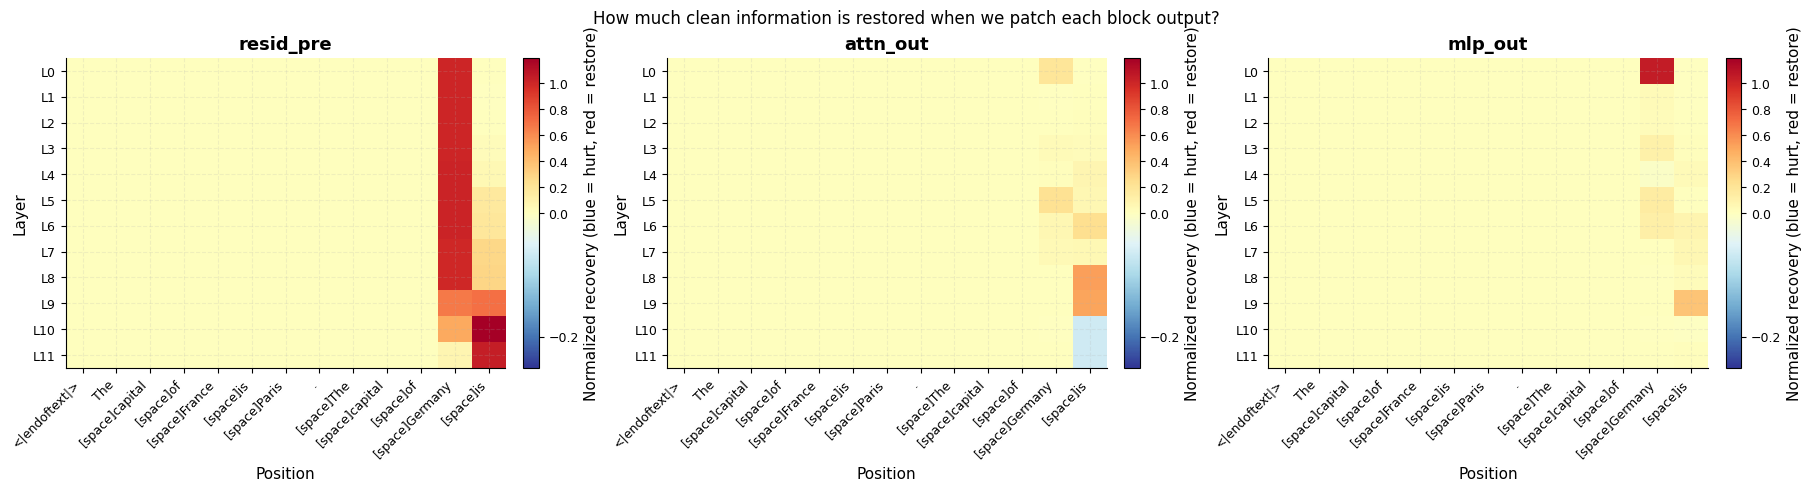

### How to read the block patching heatmaps
- `rows (layers)`: Which transformer block supplied the clean activation we patched in.
- `columns (positions)`: Which token position supplied the clean activation.
- `resid_pre`: Patch the residual stream just before a layer's attention block runs.
- `attn_out`: Patch the vector written back by a layer's attention block.
- `mlp_out`: Patch the vector written back by a layer's MLP block.
- `blue cells`: Patching here hurts recovery or pushes the corrupted run even farther from the clean behavior.
- `pale cells`: Patching here changes little.
- `red cells`: Patching here restores the clean ` Berlin`-over-` Paris` behavior.
- `normalized recovery = 0`: No improvement over the corrupted run.
- `normalized recovery = 1`: Full recovery to the clean run's target-vs-rival score.

In [31]:
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    block_patch = patching.get_act_patch_block_every(
        model=model,
        corrupted_tokens=corrupted_tokens,
        clean_cache=clean_cache,
        metric=metric,
    ).detach().cpu()

block_patch_normalized = normalize_patch_scores(
    block_patch,
    clean_score=clean_score,
    corrupted_score=corrupted_score,
)
plot_block_patching(block_patch_normalized, [visible_token(token) for token in model.to_str_tokens(CLEAN_PROMPT)])
plt.show()

display_field_guide(
    "How to read the block patching heatmaps",
    {
        "rows (layers)": "Which transformer block supplied the clean activation we patched in.",
        "columns (positions)": "Which token position supplied the clean activation.",
        "resid_pre": "Patch the residual stream just before a layer's attention block runs.",
        "attn_out": "Patch the vector written back by a layer's attention block.",
        "mlp_out": "Patch the vector written back by a layer's MLP block.",
        "blue cells": "Patching here hurts recovery or pushes the corrupted run even farther from the clean behavior.",
        "pale cells": "Patching here changes little.",
        "red cells": "Patching here restores the clean ` Berlin`-over-` Paris` behavior.",
        "normalized recovery = 0": "No improvement over the corrupted run.",
        "normalized recovery = 1": "Full recovery to the clean run's target-vs-rival score.",
    },
)


In [32]:
patch_labels = ["resid_pre", "attn_out", "mlp_out"]
best_block_flat_idx = int(block_patch_normalized.argmax().item())
best_patch_type_idx, best_layer_idx, best_position_idx = np.unravel_index(best_block_flat_idx, block_patch_normalized.shape)
best_patch_type = patch_labels[best_patch_type_idx]
best_patch_token = visible_token(model.to_str_tokens(CLEAN_PROMPT)[best_position_idx])
best_patch_score = block_patch_normalized[best_patch_type_idx, best_layer_idx, best_position_idx].item()

display_takeaways(
    title="Reading the block patching heatmaps",
    what="Normalized recovery scores showing how much of the clean target-vs-rival behavior comes back when we patch each block output into the corrupted run.",
    change=(f"The strongest block-level recovery appears at {best_patch_type} in layer {best_layer_idx} at token position {best_patch_token}, with normalized recovery {best_patch_score:0.3f}."),
    why="This tells us where the clean evidence for the answer is stored in a causal sense, not just where the final logits happen to look favorable.",
    practice="For a business-critical workflow, patching points to the smallest part of the computation worth reviewing first when a model update changes behavior.",
)


### Reading the block patching heatmaps
- What we are looking at: Normalized recovery scores showing how much of the clean target-vs-rival behavior comes back when we patch each block output into the corrupted run.
- What changes here: The strongest block-level recovery appears at resid_pre in layer 10 at token position [space]is, with normalized recovery 1.192.
- Why it matters: This tells us where the clean evidence for the answer is stored in a causal sense, not just where the final logits happen to look favorable.
- Why this matters in practice: For a business-critical workflow, patching points to the smallest part of the computation worth reviewing first when a model update changes behavior.

### Head-level patching shortlist

,layer,head,label,score
0,9,8,L9H8,0.4767
1,8,11,L8H11,0.4330
2,10,0,L10H0,0.2407
3,5,1,L5H1,0.1478
4,6,7,L6H7,0.1390
5,8,5,L8H5,0.1290
6,7,6,L7H6,0.0998
7,6,10,L6H10,0.0751
8,0,1,L0H1,0.0686
9,10,10,L10H10,0.0682


### How to read the head patching table
- `layer`: Which transformer block the patched head belongs to.
- `head`: Which head within that layer was patched.
- `label`: Readable shorthand such as `L9H8`.
- `score`: Normalized recovery after patching that head's output back into the corrupted run.

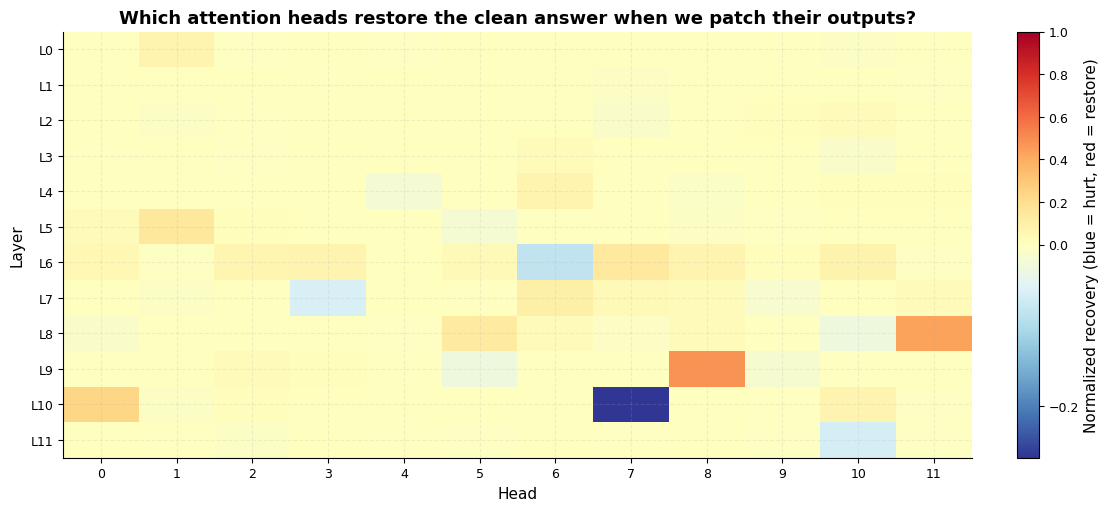

### How to read the head patching heatmap colors
- `blue cells`: Patching this head hurts recovery or pushes the corrupted run farther away from the clean behavior.
- `pale cells`: Patching this head changes very little.
- `red cells`: Patching this head restores the clean answer signal.

In [33]:
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    head_patch_all = patching.get_act_patch_attn_head_all_pos_every(
        model=model,
        corrupted_tokens=corrupted_tokens,
        clean_cache=clean_cache,
        metric=metric,
    ).detach().cpu()

head_out_patch_normalized = normalize_patch_scores(
    head_patch_all[0],
    clean_score=clean_score,
    corrupted_score=corrupted_score,
)
head_patch_df = head_scores_to_df(head_out_patch_normalized)

display(Markdown("### Head-level patching shortlist"))
display(head_patch_df.head(12))
display_field_guide(
    "How to read the head patching table",
    {
        "layer": "Which transformer block the patched head belongs to.",
        "head": "Which head within that layer was patched.",
        "label": "Readable shorthand such as `L9H8`.",
        "score": "Normalized recovery after patching that head's output back into the corrupted run.",
    },
)
plot_head_patching(head_out_patch_normalized)
plt.show()

display_field_guide(
    "How to read the head patching heatmap colors",
    {
        "blue cells": "Patching this head hurts recovery or pushes the corrupted run farther away from the clean behavior.",
        "pale cells": "Patching this head changes very little.",
        "red cells": "Patching this head restores the clean answer signal.",
    },
)


In [34]:
top_patch_head = head_patch_df.iloc[0]

display_takeaways(
    title="Reading the head patching heatmap",
    what="Normalized recovery after patching each attention head's output into the corrupted run.",
    change=(f"The strongest head-level recovery comes from {top_patch_head['label']} with normalized recovery {top_patch_head['score']:0.3f}."),
    why="If a small number of heads restore most of the clean behavior, we have a much tighter mechanistic hypothesis than saying the whole model somehow did it.",
    practice="This gives delivery or review teams a concrete shortlist of components to monitor after a model change rather than a vague suspicion that the entire model shifted.",
)


### Reading the head patching heatmap
- What we are looking at: Normalized recovery after patching each attention head's output into the corrupted run.
- What changes here: The strongest head-level recovery comes from L9H8 with normalized recovery 0.477.
- Why it matters: If a small number of heads restore most of the clean behavior, we have a much tighter mechanistic hypothesis than saying the whole model somehow did it.
- Why this matters in practice: This gives delivery or review teams a concrete shortlist of components to monitor after a model change rather than a vague suspicion that the entire model shifted.

## 6. What fails when we remove the candidate heads?

Patching tells us which heads can bring the clean behavior back. Ablation asks the complementary question: if we remove those same heads on the clean prompt, how much of the answer falls apart? This is the cleanest way to separate an active mechanism from a correlated bystander.

### Why ablation is the stricter test

- Patching asks whether a component **can carry** the clean behavior.
- Ablation asks whether a component is **needed** for the clean behavior that the model actually uses.

The strongest case is when the same small set of heads both restores the answer under patching and damages it when removed from the clean run.


In [35]:
candidate_heads_df = head_patch_df.head(HEADS_TO_ABLATE).copy()
with torch.inference_mode():
    baseline_metric = metric(model(clean_tokens)).item()

ablation_rows = []
for row in candidate_heads_df.itertuples(index=False):
    ablation_rows.append(
        ablate_single_head_and_score(
            model=model,
            tokens=clean_tokens,
            layer=int(row.layer),
            head=int(row.head),
            metric_fn=metric,
            baseline_score=baseline_metric,
        )
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("delta").reset_index(drop=True)
display(ablation_df)

display_field_guide(
    "How to read the ablation table",
    {
        "label": "Which attention head was zeroed out.",
        "baseline_score": "The target-vs-rival score before removing that head.",
        "ablated_score": "The same score after zeroing that head's output.",
        "delta": "Ablated minus baseline. More negative means the head was more important for the answer.",
    },
)


,layer,head,label,baseline_score,ablated_score,delta
0,8,11,L8H11,3.9636,2.5284,-1.4352
1,10,0,L10H0,3.9636,3.5208,-0.4429
2,9,8,L9H8,3.9636,3.6284,-0.3353
3,5,1,L5H1,3.9636,3.8242,-0.1394
4,6,7,L6H7,3.9636,3.8376,-0.1260
5,8,5,L8H5,3.9636,3.8987,-0.0649


### How to read the ablation table
- `label`: Which attention head was zeroed out.
- `baseline_score`: The target-vs-rival score before removing that head.
- `ablated_score`: The same score after zeroing that head's output.
- `delta`: Ablated minus baseline. More negative means the head was more important for the answer.

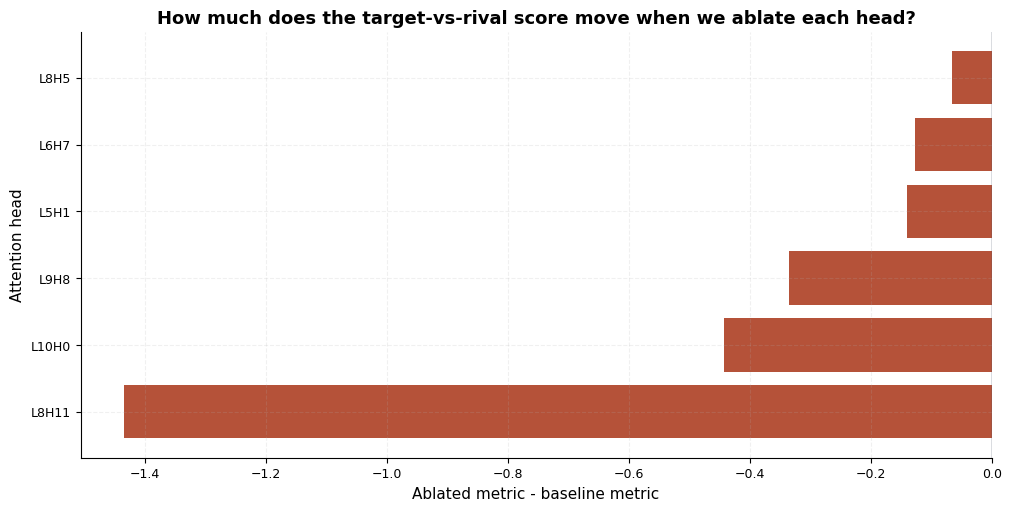

In [36]:
plot_ablation_effects(ablation_df)
plt.show()


In [37]:
most_harmful_head = ablation_df.iloc[0]

display_takeaways(
    title="Reading the ablation chart",
    what="The change in the target-minus-rival score after zeroing out each candidate head on the clean prompt.",
    change=(f"Ablating {most_harmful_head['label']} produces the largest drop, with delta {most_harmful_head['delta']:0.3f}."),
    why="This is the strongest evidence in the notebook that a small set of heads are not just correlated with the answer. They matter to producing it.",
    practice="Ablation helps separate components that are genuinely carrying workflow-relevant behavior from components that merely happen to light up at the same time.",
)


### Reading the ablation chart
- What we are looking at: The change in the target-minus-rival score after zeroing out each candidate head on the clean prompt.
- What changes here: Ablating L8H11 produces the largest drop, with delta -1.435.
- Why it matters: This is the strongest evidence in the notebook that a small set of heads are not just correlated with the answer. They matter to producing it.
- Why this matters in practice: Ablation helps separate components that are genuinely carrying workflow-relevant behavior from components that merely happen to light up at the same time.

## 7. What is the simplest story that fits all of the evidence?

By this point we have three kinds of evidence: a temporal story from the checkpoints, a directional story from attribution and attention inspection, and a causal story from patching and ablation. The goal is not to claim a universal theorem about transformers. It is to end with the simplest mechanism that fits this run and would still be useful if the behavior changed later.


In [38]:
final_summary_lines = [
    "### Final summary",
    "The evidence fits a staged story rather than a single late surprise.",
    "#### Residual-stream story",
    f"- Stage 1: early checkpoints are dominated by generic token fragments and weak lexical priors; {visible_token(TARGET_ANSWER)} is present but not yet competitive.",
    f"- Stage 2: by {first_target_top10}, {visible_token(TARGET_ANSWER)} enters the serious shortlist, which means the residual stream is finally carrying enough country-specific evidence for the answer to compete with realistic alternatives.",
    f"- Stage 3: late attention writes around {first_target_top} to {peak_target_label} do the decisive routing work and push {visible_token(TARGET_ANSWER)} into rank 1.",
    "- Stage 4: later writes rebalance confidence after the peak, but the winner stays fixed and the residual direction remains aligned with the final answer state.",
    "#### Evidence chain",
    f"- Temporal: {visible_token(TARGET_ANSWER)} first beats {visible_token(RIVAL_ANSWER)} at {first_target_beats_rival}, enters the top 10 at {first_target_top10}, and reaches rank 1 at {first_target_top}.",
    f"- Directional: the strongest overall residual contributor is {top_component['component']} ({top_component['logit_attr']:0.3f}), while {top_attention_head['label']} is the strongest attention head by attribution ({top_attention_head['logit_attr']:0.3f}).",
    f"- Causal recovery: the strongest block patch site is {best_patch_type} in layer {best_layer_idx} on {best_patch_token} ({best_patch_score:0.3f}), and the strongest head patch site is {top_patch_head['label']} ({top_patch_head['score']:0.3f}).",
    f"- Causal necessity: ablating {most_harmful_head['label']} causes the largest drop in the target-vs-rival score ({most_harmful_head['delta']:0.3f}).",
    "#### Practical reading",
    "- If a later prompt change, fine-tune, or model upgrade breaks this behavior, the same checkpoints, patch sites, and heads become the first places worth inspecting.",
]
display(Markdown("\n".join(final_summary_lines)))


### Final summary
The evidence fits a staged story rather than a single late surprise.
#### Residual-stream story
- Stage 1: early checkpoints are dominated by generic token fragments and weak lexical priors; [space]Berlin is present but not yet competitive.
- Stage 2: by L7 attn, [space]Berlin enters the serious shortlist, which means the residual stream is finally carrying enough country-specific evidence for the answer to compete with realistic alternatives.
- Stage 3: late attention writes around L8 attn to L10 pre do the decisive routing work and push [space]Berlin into rank 1.
- Stage 4: later writes rebalance confidence after the peak, but the winner stays fixed and the residual direction remains aligned with the final answer state.
#### Evidence chain
- Temporal: [space]Berlin first beats [space]Paris at L0 pre, enters the top 10 at L7 attn, and reaches rank 1 at L8 attn.
- Directional: the strongest overall residual contributor is 9_mlp_out (4.113), while L9H8 is the strongest attention head by attribution (3.534).
- Causal recovery: the strongest block patch site is resid_pre in layer 10 on [space]is (1.192), and the strongest head patch site is L9H8 (0.477).
- Causal necessity: ablating L8H11 causes the largest drop in the target-vs-rival score (-1.435).
#### Practical reading
- If a later prompt change, fine-tune, or model upgrade breaks this behavior, the same checkpoints, patch sites, and heads become the first places worth inspecting.

## Why this kind of analysis matters once models enter real workflows

- Release triage: When a model, prompt, or retrieval change breaks a workflow, the same sequence of plots helps narrow the failure from “the model changed” to “this stage or head stopped carrying the right evidence.”
- Evidence for stakeholders: Product owners, review leads, assurance partners, and risk reviewers usually need more than a benchmark delta. Mechanistic traces provide a clearer explanation of what changed and where.
- Targeted validation: If a critical behavior depends on a small number of components or late-stage patches, teams can focus red-team prompts and regression checks on that part of the computation.
- Change governance: A model upgrade can preserve surface accuracy while shifting to a different internal route. Knowing that route changed is useful when robustness matters more than a one-off success rate.
- Operational trust: Trust is easier to defend when it is tied to inspected behavior, causal tests, and known failure points rather than a vague sense that the model “seems fine.”

This notebook stays intentionally local. That is a strength, not a weakness. In practice, teams usually investigate one fragile behavior at a time, build a reusable debugging pattern, and then decide where deeper interpretability work is worth the effort.


## Appendix: optional MLP / neuron drill-down

The main story above is already complete. This appendix is for the reader who wants one more level of resolution.

TransformerLens can decompose the final residual stream more finely than “attention vs. MLP.” That means we can inspect which later MLP outputs, and sometimes which neuron-level components, contribute to the target logit. This view is useful when the high-level head story is clear but the reader wants to know what other residual contributors are still active nearby.

It is optional because it is easier to over-read than the earlier sections. The tables can get dense fast, and the signals are less intuitive than the checkpoint, attention, and patching views. The safest way to read this appendix is as a follow-up ranking, not as a replacement for the earlier causal story.


In [39]:
try:
    full_resid, full_labels = cache.get_full_resid_decomposition(layer=model.cfg.n_layers, return_labels=True)
    full_attrs = cache.logit_attrs(full_resid, TARGET_ANSWER)
    full_df = attrs_to_df(full_labels, full_attrs)
    display(full_df.head(25))

    display_field_guide(
        "How to read the appendix table",
        {
            "component": "A more fine-grained residual contributor, often including specific MLP or neuron-like outputs.",
            "logit_attr": "How much that contributor pushes the answer token upward or downward at the final position.",
        },
    )
except Exception as exc:
    print("Optional neuron-level drill-down was skipped.")
    print("Reason:", repr(exc))


,component,logit_attr
0,L9H8,3.5336
1,L8H11,2.7069
2,L9N1409,2.3655
3,L10H0,1.2767
4,L9N2649,1.0650
5,L8H6,0.8963
6,bias,0.8877
7,L10H3,0.8028
8,L11H3,0.6526
9,L8H8,0.6497


### How to read the appendix table
- `component`: A more fine-grained residual contributor, often including specific MLP or neuron-like outputs.
- `logit_attr`: How much that contributor pushes the answer token upward or downward at the final position.